# Mirror-CFE: MNIST (alle 3 Ziffernpaare) — inkl. Decoder-Training
Alle drei Ziffernpaare (3-8, 4-9, 5-6) werden in **einem** Durchlauf nacheinander trainiert
und ausgewertet -- der gesamte Trainings-/Auswertungs-Code pro Paar ist unveraendert, nur in
eine Funktion `run_mirror_pipeline(pair_key)` verpackt.

**Metriken werden zweimal berechnet:**
- **1st-CFE** (Standard): kleinstes `k`, bei dem das dekodierte Bild tatsaechlich flippt
- **k=1**: fix am vollen Reflexionspunkt

Am Ende werden **beide** Metrik-Saetze ueber alle drei Paare gemittelt ausgegeben.

### Outputs
- `./mirror_decoder_<PAIR_KEY>.pth` -- pro Paar
- `./metrics_summary_mirror.csv` -- 3 Paare x 2 Varianten + 2 `MEAN`-Zeilen (first_cfe, k1)


## 1. Imports & globale Konfiguration

In [1]:
import os
import time
import struct
import numpy as np
from array import array
from os.path import join
from tqdm import tqdm
from collections import OrderedDict
from functools import partial

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Geraet:', DEVICE)

# ── Alle drei Ziffernpaare -- werden unten in einer Schleife nacheinander durchlaufen ──
TASK_PAIRS = {'38': (3, 8), '49': (4, 9), '56': (5, 6)}

# ── Pfade (MNIST-Rohdaten, IDX-Format, wie auf Kaggle bereitgestellt) ─────────
INPUT_PATH = '/kaggle/input/datasets/hojjatk/mnist-dataset'
TRAIN_IMAGES_PATH = join(INPUT_PATH, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
TRAIN_LABELS_PATH = join(INPUT_PATH, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
TEST_IMAGES_PATH  = join(INPUT_PATH, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
TEST_LABELS_PATH  = join(INPUT_PATH, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')
OUT_DIR   = '/kaggle/working'

IMAGE_SIZE = 32                      # 28 -> 32 fuer saubere dyadische Downsampling-Stufen
MNIST_MEAN = [0.5]                   # 0.5/0.5 -- konsistent mit dem Klassifikator-Checkpoint
MNIST_STD  = [0.5]
BATCH_SIZE = 64

# ── Mirror-Decoder Hyperparameter (identisch zur Fire-Version) ───────────────
DEC_LR      = 2e-4
DISC_LR     = 2e-4
DEC_EPOCHS  = 15
ALPHA       = 0.2
RHO_L       = 0.1
RHO_U       = 0.5

W_CLS  = 1.0
W_ADV  = 1.0
W_REC  = 1.0
W_FEA  = 1.0
W_TRI  = 2.0

# Fester Eval-Satz (auch global, damit die Aggregation am Ende darauf zugreifen kann)
EVAL_SEED     = 42
N_EVAL_IMAGES = 80
DENOISE_SIGMA = 1.0


Geraet: cuda


## 2. Dataset (global -- MNIST wird einmal komplett geladen)

In [2]:
class MnistDataloader(object):
    """IDX-Format-Loader fuer MNIST (liest die rohen Kaggle-Dateien direkt, kein Download noetig)."""
    def __init__(self, training_images_filepath, training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath

    def read_images_labels(self, images_filepath, labels_filepath):
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError(f'Magic number mismatch, expected 2049, got {magic}')
            labels = array("B", file.read())
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError(f'Magic number mismatch, expected 2051, got {magic}')
            image_data = array("B", file.read())
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img
        return images, labels

    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train), (x_test, y_test)


mnist_dataloader = MnistDataloader(TRAIN_IMAGES_PATH, TRAIN_LABELS_PATH, TEST_IMAGES_PATH, TEST_LABELS_PATH)
(x_train_all, y_train_all), (x_test_all, y_test_all) = mnist_dataloader.load_data()
x_train_all = np.array(x_train_all, dtype=np.uint8)
y_train_all = np.array(y_train_all, dtype=np.int64)
x_test_all  = np.array(x_test_all,  dtype=np.uint8)
y_test_all  = np.array(y_test_all,  dtype=np.int64)
print(f'MNIST geladen (IDX-Format) -- Train: {x_train_all.shape}  Test: {x_test_all.shape}')


def filter_and_remap(images, labels, d0, d1):
    """Behaelt nur Bilder von d0/d1, remapped Labels auf {0,1} (0=d0, 1=d1)."""
    mask = (labels == d0) | (labels == d1)
    imgs_f = images[mask]
    lbls_f = np.where(labels[mask] == d0, 0, 1).astype(np.int64)
    return imgs_f, lbls_f


class MNISTPairDataset(Dataset):
    """Nimmt bereits gefilterte (images, labels)-Arrays (uint8 28x28, Labels 0/1) und wendet
    die torchvision-Transform-Pipeline an. Gibt zusaetzlich einen synthetischen Dateinamen
    zurueck (Interface-Kompatibilitaet mit Fire-/X-Ray-Notebooks)."""
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        label = int(self.labels[idx])
        if self.transform is not None:
            img = self.transform(img)
        fname = f'{idx:06d}.png'
        return img, label, fname

print('MnistDataloader + MNISTPairDataset definiert OK')


MNIST geladen (IDX-Format) -- Train: (60000, 28, 28)  Test: (10000, 28, 28)
MnistDataloader + MNISTPairDataset definiert OK


## 4. Klassifikator-Architektur (global -- Gewichte werden pro Paar geladen)

In [3]:
class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    """Gate-Defaults identisch zum Original-ResNet18 (Fire/X-Ray): kernel=7, stride=2,
    padding=3, pool=True. Bei 32x32-MNIST-Eingaben ergibt das die Pyramide
    f1@8 f2@4 f3@2 f4@1 (512 Kanaele) -- proportional identisch zu Fire (224->7)."""
    def __init__(self, in_channels=1, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock,
                 gate_kernel=7, gate_stride=2, gate_padding=3, gate_pool=True,
                 *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        gate_layers = [
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=gate_kernel,
                      stride=gate_stride, padding=gate_padding, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
        ]
        if gate_pool:
            gate_layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
        self.gate = nn.Sequential(*gate_layers)
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_model():
    # Gate UNVERAENDERT (Defaults oben) -- identische Architektur wie das
    # Klassifikator-Training in mnist-resnet18-training.ipynb.
    return ResNet(in_channels=1, n_classes=2, block=ResNetBasicBlock, depths=[2, 2, 2, 2])

## 5. Mirror-CFE Kernfunktionen, Hilfsfunktionen & KFE-Visualisierung (global)

In [4]:
def extract_feature_maps(model, images):
    """Feature Maps aus dem letzten Encoder-Block. Rueckgabe: (B, 512, 1, 1)"""
    feat = []
    hook = model.encoder.blocks[-1].register_forward_hook(lambda m, i, o: feat.append(o))
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    return feat[0]

def get_boundary_params(model):
    """Entscheidungsgrenze: Wm = W[1] - W[0], bm = b[1] - b[0]. Zeigt Richtung Klasse 1."""
    W  = model.decoder.decoder.weight.data
    b  = model.decoder.decoder.bias.data
    Wm = W[1] - W[0]
    bm = b[1] - b[0]
    return Wm, bm

def position_function(zs_batch, Wm, bm, k):
    """Paper Eq. 1: P(zs, Wm, bm, k) = zs - 2k*(Wm^T*zs+bm)*What"""
    B, C, H, W = zs_batch.shape
    W_hat   = Wm / (Wm.norm() + 1e-8)
    zs_flat = zs_batch.view(B, C, -1)
    dot     = (Wm.view(1, C, 1) * zs_flat).sum(dim=1, keepdim=True)
    scalar  = dot + bm.item()
    delta   = 2 * k * scalar * W_hat.view(1, C, 1)
    return (zs_flat - delta).view(B, C, H, W)

def compute_flk(f4_s, zs, Wm, bm, k):
    """Rekonstruiert die KFE-Feature-Map f^l_k EXAKT wie im Decoder-Training
    (Supp. Eq. 17): gleichmaessiger Kanal-Shift, sodass GAP(f^l_k) = z_k gilt."""
    B, C, H, Wd = f4_s.shape
    W_hat = Wm / (Wm.norm() + 1e-8)
    dot   = (Wm.view(1, C) * zs).sum(1, keepdim=True) + bm
    z_delta = -2.0 * k * dot * W_hat.view(1, C)
    zk  = zs + z_delta
    flk = f4_s + z_delta.view(B, C, 1, 1)
    return flk, zk

def refine_with_lbfgs(model, zr_init, source_labels, cfe_labels, orig_probs_2cls, num_iterations=20):
    """L-BFGS Verfeinerung bis der Decoder die Zielklasse ausgibt."""
    swapped = orig_probs_2cls.clone().detach()
    idx = torch.arange(len(cfe_labels))
    src = source_labels.view(-1)
    cfe = cfe_labels.view(-1)
    tmp = swapped[idx, cfe].clone()
    swapped[idx, cfe] = swapped[idx, src]
    swapped[idx, src] = tmp

    z = Variable(zr_init.clone().detach(), requires_grad=True)
    optimizer = torch.optim.LBFGS([z], lr=0.1)

    def closure():
        optimizer.zero_grad()
        pooled = F.adaptive_avg_pool2d(z, (1, 1))
        flat   = torch.flatten(pooled, 1)
        logits = model.decoder.decoder(flat)
        probs  = torch.softmax(logits, dim=1)
        loss   = torch.norm(probs - swapped) ** 2
        loss.backward()
        return loss

    for _ in range(num_iterations):
        optimizer.step(closure)
    return z

def compute_mirror_cfe(model, images, device, num_iterations=20):
    """Vollstaendige Mirror-CFE Pipeline."""
    model.eval()
    images = images.to(device)
    with torch.no_grad():
        logits        = model(images)
        probs         = torch.softmax(logits, dim=1)
        orig_probs    = probs[:, 1]
        source_labels = logits.argmax(dim=1)
        cfe_labels    = 1 - source_labels

    zs     = extract_feature_maps(model, images)
    Wm, bm = get_boundary_params(model)
    Wm, bm = Wm.to(device), bm.to(device)

    with torch.no_grad():
        zr_geometric = position_function(zs.clone(), Wm, bm, k=1.0)

    mirror_fv = refine_with_lbfgs(model, zr_geometric, source_labels, cfe_labels,
                                  probs.clone(), num_iterations=num_iterations)
    return mirror_fv, cfe_labels, source_labels, orig_probs

print('Mirror-CFE Funktionen definiert OK')



def denormalise(tensor):
    """Funktioniert fuer 3D (C,H,W) und 4D (B,C,H,W) Tensoren."""
    if tensor.dim() == 3:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1)
    else:
        mean = torch.tensor(MNIST_MEAN, device=tensor.device).view(1,1,1,1)
        std  = torch.tensor(MNIST_STD,  device=tensor.device).view(1,1,1,1)
    return (tensor * std + mean).clamp(0, 1)

def renormalise(img01):
    mean = torch.tensor(MNIST_MEAN, device=img01.device).view(1,1,1,1)
    std  = torch.tensor(MNIST_STD,  device=img01.device).view(1,1,1,1)
    return (img01 - mean) / std

def tanh_to_img(tensor):
    """Decoder-Output [-1,1] -> [0,1]"""
    return (tensor + 1.0) / 2.0

def predict_from_features(model, feature_maps):
    """Gibt P(Klasse 1) zurueck."""
    with torch.no_grad():
        pooled = F.adaptive_avg_pool2d(feature_maps, (1, 1))
        flat   = torch.flatten(pooled, 1)
        logits = model.decoder.decoder(flat)
        probs  = torch.softmax(logits, dim=1)[:, 1]
    return probs

print('Hilfsfunktionen definiert OK')



def generate_kfe_transitions(zs, zr, k_steps=None):
    """KFE-Uebergaenge: lineare Interpolation von zs nach zr."""
    if k_steps is None:
        k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions = []
    with torch.no_grad():
        for k in k_steps:
            zk = (1 - k) * zs + k * zr.detach()
            transitions.append(zk)
    return transitions, k_steps


def visualise_cfe(model, images, labels, fnames, mirror_fv, cfe_labels, source_labels,
                  orig_probs, class_names, n_samples=4, save_path='mirror_cfe.png'):
    """Zeile pro Sample: Original | KFE-Uebergang k=0..1 (Heatmaps) | (kein BBox-Overlay, MNIST hat keine)."""
    model.eval()
    images = images.to(DEVICE)
    n = min(n_samples, images.size(0))

    source_fv = extract_feature_maps(model, images[:n])
    k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions, ks = generate_kfe_transitions(source_fv, mirror_fv[:n], k_steps)

    conf_matrix = []
    for zk in transitions:
        p = predict_from_features(model, zk).cpu().numpy()
        conf_matrix.append(p)

    with torch.no_grad():
        cfe_logits = model.decoder.decoder(torch.flatten(F.adaptive_avg_pool2d(mirror_fv[:n], (1,1)), 1))
        cfe_probs = torch.softmax(cfe_logits, dim=1)[:, 1].cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    n_cols = 1 + len(k_steps)
    fig = plt.figure(figsize=(n_cols * 2.4, n * 3.2))
    gs  = gridspec.GridSpec(n, n_cols, figure=fig, hspace=0.6, wspace=0.25)

    k_labels = ['k=0\n(Quelle)', 'k=0.25', 'k=0.5\n(Grenze)', 'k=0.6\n(1. CFE)', 'k=0.75', 'k=1.0\n(Reflexion)']

    for i in range(n):
        img_np   = denormalise(images[i].cpu()).squeeze(0).numpy()
        src_lbl  = source_labels[i].item()
        cfe_lbl  = cfe_labels[i].item()
        true_lbl = int(labels[i])
        flipped  = int(cfe_probs[i] >= 0.5) == cfe_lbl

        ax0 = fig.add_subplot(gs[i, 0])
        ax0.imshow(img_np, cmap='gray')
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'
        ax0.set_title(f'Original\nWahr: {class_names[true_lbl]}\nPred: {class_names[src_lbl]}\n({orig_probs_np[i]:.1%})',
                     fontsize=7, color=pred_col)
        ax0.axis('off')

        for j, (zk, k_lbl) in enumerate(zip(transitions, k_labels)):
            ax = fig.add_subplot(gs[i, j + 1])
            hmap = zk[i].detach().cpu().mean(0).numpy()
            hmap = (hmap - hmap.min()) / (hmap.max() + 1e-8)
            ax.imshow(hmap, cmap='hot', interpolation='bilinear', vmin=0, vmax=1)
            p_k = conf_matrix[j][i]
            pred_at_k = class_names[int(p_k >= 0.5)]
            cross_col = 'cyan' if (int(p_k >= 0.5) == cfe_lbl) else 'white'
            ax.text(0.5, 0.02, f'P(Kl.1)={p_k:.2f}\n{pred_at_k}', transform=ax.transAxes,
                    ha='center', va='bottom', fontsize=6, color=cross_col,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))
            ax.set_title(k_lbl, fontsize=7)
            ax.axis('off')

    plt.suptitle(f'Mirror-CFE KFE-Uebergang — Paar {PAIR_KEY}  (grün Rahmen impliziert Flip bei k=1)', fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert -> {save_path}')

print('Visualisierungsfunktion definiert OK')


Mirror-CFE Funktionen definiert OK
Hilfsfunktionen definiert OK
Visualisierungsfunktion definiert OK


## 10-11. SSC + Mirror-Decoder/Discriminator — Klassen (global)

In [5]:
class SPEBlock(nn.Module):
    """Spatial Pattern Editor fuer eine Skip-Ebene (Paper Eq. 12).
    flk_spatial: raeumliche Aufloesung von flk (1 fuer MNIST, 7 fuer Fire/X-Ray)."""
    def __init__(self, Ci, Hi, flk_ch=512, bottleneck_ch=128, flk_spatial=1):
        super().__init__()
        self.Hi = Hi
        self.bottleneck = nn.Sequential(
            nn.Conv2d(Ci, bottleneck_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(bottleneck_ch),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((flk_spatial, flk_spatial)),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(bottleneck_ch + flk_ch, Ci, kernel_size=3, padding=1),
            nn.BatchNorm2d(Ci),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(Hi, Hi), mode='bilinear', align_corners=False),
            nn.Conv2d(Ci, Ci, kernel_size=3, padding=1),
            nn.BatchNorm2d(Ci),
            nn.ReLU(inplace=True),
        )
    def forward(self, fi_s, flk):
        bi  = self.bottleneck(fi_s)
        cat = torch.cat([bi, flk], dim=1)
        return self.decoder(cat)


class SSC(nn.Module):
    """Skip-Connection-Controller = SPE (3 Ebenen) + CSP-Maskierung.
    MNIST-Pyramide: f1@8x8 (64 Kanaele), f2@4x4 (128), f3@2x2 (256)."""
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.rho_l = rho_l
        self.rho_u = rho_u
        self.spe1 = SPEBlock(64,  8, flk_spatial=1)
        self.spe2 = SPEBlock(128, 4, flk_spatial=1)
        self.spe3 = SPEBlock(256, 2, flk_spatial=1)

    def csp_mask(self, flk, W, k, target_hw, src_cls, tgt_cls):
        B, C, H, Wd = flk.shape
        Uk = torch.einsum('oc,bchw->bohw', W, flk)
        Uk = F.relu(Uk)
        mx = Uk.amax(dim=(2, 3), keepdim=True) + 1e-8
        Nk = Uk / mx
        rho = min(max(1.0 - k, self.rho_l), self.rho_u)
        idx = torch.arange(B, device=flk.device)
        Ns = (Nk[idx, src_cls].unsqueeze(1) > rho).float()
        Nt = (Nk[idx, tgt_cls].unsqueeze(1) > rho).float()
        M  = torch.clamp(Ns + Nt, 0.0, 1.0)
        return F.interpolate(M, size=target_hw, mode='nearest')

    def forward(self, f1_s, f2_s, f3_s, flk, W, k, src_cls, tgt_cls):
        u1 = self.spe1(f1_s, flk)
        u2 = self.spe2(f2_s, flk)
        u3 = self.spe3(f3_s, flk)
        m1 = self.csp_mask(flk, W, k, (8, 8), src_cls, tgt_cls)
        m2 = self.csp_mask(flk, W, k, (4, 4), src_cls, tgt_cls)
        m3 = self.csp_mask(flk, W, k, (2, 2), src_cls, tgt_cls)
        fp1 = (1 - m1) * f1_s + m1 * u1
        fp2 = (1 - m2) * f2_s + m2 * u2
        fp3 = (1 - m3) * f3_s + m3 * u3
        return fp1, fp2, fp3

print('SSC (SPE + CSP) definiert OK')



class MirrorDecoder(nn.Module):
    """SkipDecoder-Basis + integriertes SSC -- 1:1 dieselbe Struktur wie im
    Fire-Notebook (5 Upsample-Stufen, gleiche Kanalzahlen), nur auf die kleinere
    MNIST-Pyramide angewandt (1->2->4->8->16->32, 1 Ausgabekanal statt 3)."""
    def __init__(self, rho_l=0.1, rho_u=0.5):
        super().__init__()
        self.ssc = SSC(rho_l=rho_l, rho_u=rho_u)
        self.up1 = self._up_block(512, 256)   # 1 -> 2   (+skip fp3: 256)
        self.up2 = self._up_block(512, 128)   # 2 -> 4   (+skip fp2: 128)
        self.up3 = self._up_block(256, 64)    # 4 -> 8   (+skip fp1: 64)
        self.up4 = self._up_block(128, 32)    # 8 -> 16
        self.up5 = self._up_block(32,  16)    # 16 -> 32 (final)
        self.out_conv = nn.Sequential(
            nn.Conv2d(16, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )
    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def _decode(self, flk, fp1, fp2, fp3):
        x = self.up1(flk)                 # 1 -> 2  (256 ch)
        x = torch.cat([x, fp3], dim=1)    # 256+256 = 512 ch @2x2
        x = self.up2(x)                   # 2 -> 4  (128 ch)
        x = torch.cat([x, fp2], dim=1)    # 128+128 = 256 ch @4x4
        x = self.up3(x)                   # 4 -> 8  (64 ch)
        x = torch.cat([x, fp1], dim=1)    # 64+64 = 128 ch @8x8
        x = self.up4(x)                   # 8 -> 16 (32 ch)
        x = self.up5(x)                   # 16 -> 32 (16 ch)
        return self.out_conv(x)
    def forward(self, flk, f1_s, f2_s, f3_s, W, k, src_cls, tgt_cls):
        fp1, fp2, fp3 = self.ssc(f1_s, f2_s, f3_s, flk, W, k, src_cls, tgt_cls)
        return self._decode(flk, fp1, fp2, fp3)


class PatchDiscriminator(nn.Module):
    """PatchGAN-Diskriminator fuer L_adv (Paper Eq. 3), an 32x32-Graustufenbilder angepasst
    (Fire: 224->112->56->28->14 mit 4 Bloecken; MNIST: 32->16->8->4 mit 3 Bloecken)."""
    def __init__(self, in_ch=1, ndf=64):
        super().__init__()
        def block(i, o, s=2, bn=True):
            layers = [nn.Conv2d(i, o, 4, stride=s, padding=1)]
            if bn: layers.append(nn.BatchNorm2d(o))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        self.net = nn.Sequential(
            *block(in_ch, ndf, bn=False),    # 32 -> 16
            *block(ndf, ndf*2),               # 16 -> 8
            *block(ndf*2, ndf*4),             # 8  -> 4
            nn.Conv2d(ndf*4, 1, 3, stride=1, padding=1)   # PatchMap @4x4
        )
    def forward(self, x):
        return self.net(x)


def extract_all_features(model, images):
    """Alle 4 ResNet-Ebenen (fuer den Decoder)."""
    feats = {}
    hooks = []
    layer_map = {
        'f1': model.encoder.blocks[0],   # (B,  64, 8, 8)
        'f2': model.encoder.blocks[1],   # (B, 128, 4, 4)
        'f3': model.encoder.blocks[2],   # (B, 256, 2, 2)
        'f4': model.encoder.blocks[3],   # (B, 512, 1, 1)
    }
    for name, layer in layer_map.items():
        h = layer.register_forward_hook(lambda m, i, o, n=name: feats.update({n: o}))
        hooks.append(h)
    with torch.no_grad():
        _ = model(images)
    for h in hooks:
        h.remove()
    return feats['f1'], feats['f2'], feats['f3'], feats['f4']

def gap(fmap):
    return F.adaptive_avg_pool2d(fmap, (1, 1)).flatten(1)

SSC (SPE + CSP) definiert OK


## 17. Decoder-Visualisierungsfunktion (global)

In [6]:
def visualise_decoder_cfe(model, decoder, images, labels, fnames, mirror_fv, cfe_labels,
                          source_labels, orig_probs, class_names,
                          n_samples=4, save_path='mirror_cfe_decoded.png'):
    """Drei-Panel Visualisierung pro Sample (ohne BBox-Overlay)."""
    model.eval(); decoder.eval()
    images = images.to(DEVICE)
    n = min(n_samples, images.size(0))

    f1, f2, f3, f4 = extract_all_features(model, images[:n])
    src_n = source_labels[:n].to(DEVICE)
    tgt_n = cfe_labels[:n].to(DEVICE)
    with torch.no_grad():
        cfe_imgs = decoder(mirror_fv[:n].detach(), f1, f2, f3, Wmat, 1.0, src_n, tgt_n)

    cfe_probs_val = predict_from_features(model, mirror_fv[:n]).cpu().numpy()
    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(9, n * 3.2))
    if n == 1:
        axes = axes[np.newaxis, :]
    col_titles = ['Original xᵢ', "CFE x' (Decoder)", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        orig_np = denormalise(images[i].cpu()).squeeze(0).numpy()
        cfe_np  = tanh_to_img(cfe_imgs[i].detach().cpu()).squeeze(0).numpy().clip(0, 1)
        diff_np = np.abs(cfe_np - orig_np)
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = source_labels[i].item(); cfe_lbl = cfe_labels[i].item()
        true_lbl = int(labels[i])
        flipped  = int(cfe_probs_val[i] >= 0.5) == cfe_lbl

        ax1 = axes[i, 0]; ax1.imshow(orig_np, cmap='gray')
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'
        ax1.set_ylabel(f'Wahr: {class_names[true_lbl]}\nPred: {class_names[src_lbl]} ({orig_probs_np[i]:.1%})',
                       fontsize=8, color=pred_col, rotation=0, labelpad=70, va='center')
        ax1.axis('off')

        ax2 = axes[i, 1]; ax2.imshow(cfe_np, cmap='gray')
        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        ax2.set_xlabel(f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})\n{flip_txt}', fontsize=8, color=flip_col)
        ax2.axis('off')

        ax3 = axes[i, 2]
        im = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        ax3.axis('off')

    plt.suptitle(f"Mirror-CFE + Decoder — Paar {PAIR_KEY}\nGrün = Vorhersage gekippt  |  Rot = Vorhersage nicht gekippt",
                fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert -> {save_path}')

## Metriken — Setup

In [7]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN — identisch mit FCVE fuer direkten Vergleich.
# KEINE EBPG: MNIST hat keine Bounding-Boxes (dokumentierte Abweichung von Fire/X-Ray).
# ══════════════════════════════════════════════════════════════════════════════
import time
from scipy import linalg as scipy_linalg

try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen OK')
except ImportError:
    LPIPS_AVAILABLE = False
    print('LPIPS nicht verfuegbar -- pip install lpips')


def _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm, bm, src, tgt, k):
    """Dekodiert ein KFE-Bild bei Schrittfaktor k ueber die IN-DISTRIBUTION flk."""
    flk, zk = compute_flk(f4, zs, Wm, bm, k)
    cfe_imgs = decoder(flk, f1, f2, f3, Wmat, k, src, tgt)
    return cfe_imgs, zk


def get_cfe_image_from_mirror(model, decoder, images, mirror_fv=None, k_eval=None, k_grid=None):
    """'1st CFE': pro Sample kleinstes k, bei dem das dekodierte Bild flippt.
    k_eval=None -> Suche; k_eval=1.0 -> Reflexionspunkt."""
    images = images.to(DEVICE)
    n = images.size(0)
    f1, f2, f3, f4 = extract_all_features(model, images)
    Wm_l, bm_l = get_boundary_params(model)
    Wm_l, bm_l = Wm_l.to(DEVICE), bm_l.to(DEVICE)

    with torch.no_grad():
        src = model(images).argmax(dim=1)
        tgt = 1 - src
        zs  = F.adaptive_avg_pool2d(f4, 1).flatten(1)

        if k_eval is not None:
            cfe_imgs, _ = _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm_l, bm_l, src, tgt, float(k_eval))
            k_used = torch.full((n,), float(k_eval))
        else:
            if k_grid is None:
                k_grid = [0.5 + 0.05 * i for i in range(1, 11)]
            best_imgs = None
            k_used    = torch.ones(n)
            found     = torch.zeros(n, dtype=torch.bool)
            for k in k_grid:
                cfe_k, _ = _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm_l, bm_l, src, tgt, float(k))
                cfe_img01 = tanh_to_img(cfe_k)
                _mean = torch.tensor(MNIST_MEAN, device=DEVICE).view(1,1,1,1)
                _std  = torch.tensor(MNIST_STD,  device=DEVICE).view(1,1,1,1)
                pred  = model((cfe_img01 - _mean) / _std).argmax(dim=1)
                newly = (pred.cpu() == tgt.cpu()) & (~found)
                if best_imgs is None:
                    best_imgs = cfe_k.clone()
                if newly.any():
                    best_imgs[newly] = cfe_k[newly]
                    k_used[newly]    = float(k)
                    found = found | newly
                if found.all():
                    break
            if (~found).any():
                cfe_1, _ = _decode_at_k(model, decoder, f1, f2, f3, f4, zs, Wm_l, bm_l, src, tgt, 1.0)
                best_imgs[~found] = cfe_1[~found]
            cfe_imgs = best_imgs

    orig_np = denormalise(images.cpu()).permute(0,2,3,1).numpy()
    cfe_np  = tanh_to_img(cfe_imgs.detach().cpu()).permute(0,2,3,1).numpy().clip(0,1)
    return orig_np, cfe_np


def compute_l1(orig_np, cfe_np):
    diffs = np.abs(orig_np - cfe_np)
    l1_per_sample = diffs.sum(axis=(1,2,3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1_per_sample.mean())


def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    changed = (diff > threshold).astype(float)
    return float(changed.mean(axis=(1,2)).mean())


def _gray_to_rgb(t):
    return t.repeat(1, 3, 1, 1) if t.shape[1] == 1 else t


def compute_lpips(orig_np, cfe_np):
    if not LPIPS_AVAILABLE:
        return None
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    orig_t, cfe_t = _gray_to_rgb(orig_t), _gray_to_rgb(cfe_t)
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


from torchvision.models import inception_v3

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    if not hasattr(extract_inception_features, '_model'):
        model_inc = inception_v3(weights='DEFAULT', transform_input=False)
        model_inc.fc = nn.Identity()
        model_inc = model_inc.eval().to(DEVICE)
        extract_inception_features._model = model_inc
    inc = extract_inception_features._model
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        batch = imgs_np[i:i+batch_size]
        t = torch.tensor(batch, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)
        t = _gray_to_rgb(t)
        t = torch.nn.functional.interpolate(t, size=(299,299), mode='bilinear', align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_np, fake_np):
    real_feats = extract_inception_features(real_np)
    fake_feats = extract_inception_features(fake_np)
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    sig_r = np.cov(real_feats, rowvar=False)
    sig_f = np.cov(fake_feats, rowvar=False)
    diff = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))


def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    from torchvision.transforms.functional import gaussian_blur
    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)
    if denoise_sigma is not None:
        kernel_size = int(denoise_sigma * 6) | 1
        kernel_size = max(kernel_size, 3)
        cfe_blurred = gaussian_blur(cfe_imgs_tensor, kernel_size=[kernel_size, kernel_size],
                                    sigma=[denoise_sigma, denoise_sigma])
    else:
        cfe_blurred = cfe_imgs_tensor
    mean = torch.tensor(MNIST_MEAN, device=DEVICE).view(1,1,1,1)
    std  = torch.tensor(MNIST_STD,  device=DEVICE).view(1,1,1,1)
    cfe_norm = (cfe_blurred - mean) / std
    with torch.no_grad():
        logits = model(cfe_norm)
        preds  = logits.argmax(dim=1).cpu()
    return float((preds == cfe_labels.cpu()).float().mean())


def compute_coverage(model, decoder, images, n_runs=5, num_iterations=20, k_eval=None):
    """Coverage: Anteil dekodierter CFs, deren Klasse = Zielklasse.
    k_eval=None -> 1st-CFE-Punkt (Standard); k_eval=1.0 -> Coverage am Reflexionspunkt."""
    images = images.to(DEVICE)
    valid_runs = []
    for run in range(n_runs):
        _, cfe_np = get_cfe_image_from_mirror(model, decoder, images, k_eval=k_eval)
        with torch.no_grad():
            src = model(images).argmax(dim=1)
            c_lbls = 1 - src
        cfe_t = torch.tensor(cfe_np).permute(0, 3, 1, 2).float()
        rate  = compute_validity(model, cfe_t, c_lbls)
        valid_runs.append(rate)
    return float(np.mean(valid_runs)), float(np.std(valid_runs))


print('Metrik-Funktionen definiert OK')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 63.5MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen OK
Metrik-Funktionen definiert OK


## Pipeline pro Ziffernpaar
Alles Paar-Spezifische (Datenladen, Klassifikator laden, Mirror-Decoder + Discriminator
trainieren, Visualisierung, Metriken bei 1st-CFE **und** bei k=1) steckt in dieser einen
Funktion -- inhaltlich 1:1 identisch zum bisherigen Notebook, nur parametrisiert ueber
`pair_key` statt eines global gesetzten `PAIR_KEY`.

In [9]:
def run_mirror_pipeline(pair_key):
    global PAIR_KEY, DIGIT_PAIR, CLASS_NAMES, CLS_PATH, Wmat  # von global definierten
        # Funktionen (visualise_cfe, visualise_decoder_cfe, _decode_at_k) als freie Variablen gelesen

    PAIR_KEY = pair_key

    DIGIT_PAIR = TASK_PAIRS[PAIR_KEY]

    CLASS_NAMES = {0: str(DIGIT_PAIR[0]), 1: str(DIGIT_PAIR[1])}

    CLS_PATH  = f'/kaggle/input/models/alexandernigg/mnist-{PAIR_KEY}-cnn-v2/pytorch/default/1/best_model_{PAIR_KEY}.pth'

    print('\n' + '#' * 70)

    print(f'# Mirror-CFE — Ziffernpaar {PAIR_KEY} {DIGIT_PAIR}')

    print('#' * 70)

    print(f'Paar: {PAIR_KEY} {DIGIT_PAIR}')

    print('Klassifikator-Checkpoint vorhanden:', os.path.exists(CLS_PATH))



    # ── 3. DataLoader ──

    train_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomAffine(degrees=8, translate=(0.05, 0.05)),
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ])
    eval_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ])

    imgs_f, lbls_f = filter_and_remap(x_train_all, y_train_all, *DIGIT_PAIR)

    full_ds      = MNISTPairDataset(imgs_f, lbls_f, transform=train_transforms)
    full_ds_eval = MNISTPairDataset(imgs_f, lbls_f, transform=eval_transforms)

    n_val   = int(len(full_ds) * 0.1)     # 90/10 statt 80/20
    n_train = len(full_ds) - n_val
    generator = torch.Generator().manual_seed(42)   # gleicher Seed wie Klassifikator/FCVE
    perm = torch.randperm(len(full_ds), generator=generator).tolist()
    train_idx, val_idx = perm[:n_train], perm[n_train:]

    train_split = Subset(full_ds, train_idx)
    val_dataset = Subset(full_ds_eval, val_idx)

    train_loader = DataLoader(train_split, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=False)

    print('Klassen:', CLASS_NAMES)
    print(f'Train: {len(train_split)}  Val: {len(val_dataset)}  Train-Batches: {len(train_loader)}  Val-Batches: {len(val_loader)}')



    # ── 4. Modell laden ──

    checkpoint = torch.load(CLS_PATH, map_location=DEVICE, weights_only=False)
    model      = build_model().to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    print('Modell geladen OK')
    print(f'Klassen:       {checkpoint.get("class_names")}')
    print(f'Val Accuracy:  {checkpoint.get("val_acc", "N/A")}')
    with torch.no_grad():
        dummy = torch.zeros(2, 1, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
        print('Output-Shape:', model(dummy).shape)



    # ── 8. Sanity Check -- Flip Rate & Visualisierung ──

    sample_images, sample_labels, sample_fnames = next(iter(test_loader))
    mirror_fv, cfe_lbls, src_lbls, orig_probs = compute_mirror_cfe(model, sample_images, DEVICE, num_iterations=20)

    cfe_logits_check = model.decoder.decoder(torch.flatten(F.adaptive_avg_pool2d(mirror_fv, (1,1)), 1))
    cfe_probs_check  = torch.softmax(cfe_logits_check, dim=1)[:, 1]
    cfe_preds_check  = (cfe_probs_check >= 0.5).long().cpu()
    flip_rate = (cfe_preds_check == cfe_lbls.cpu()).float().mean()
    print(f'Batch-Groesse: {len(sample_labels)}')
    print(f'Flip Rate    : {flip_rate:.2%}  (Ziel: >60%)')
    if flip_rate < 0.6:
        print('\n⚠ Flip Rate niedrig -- ggf. num_iterations erhoehen')

    visualise_cfe(
        model=model, images=sample_images, labels=sample_labels, fnames=sample_fnames,
        mirror_fv=mirror_fv, cfe_labels=cfe_lbls, source_labels=src_lbls,
        orig_probs=orig_probs, class_names=CLASS_NAMES, n_samples=4,
        save_path=os.path.join(OUT_DIR, f'mirror_cfe_kfe_{PAIR_KEY}.png')
    )



    # ── 9. Batch-Evaluation -- Flip Rate ueber mehrere Batches ──

    total_flip, total_images = 0, 0
    for batch_imgs, batch_lbls, _ in tqdm(list(test_loader)[:10], desc='Mirror-CFE Evaluation'):
        m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(model, batch_imgs, DEVICE, num_iterations=20)
        logits_b = model.decoder.decoder(torch.flatten(F.adaptive_avg_pool2d(m_fv, (1,1)), 1))
        probs_b  = torch.softmax(logits_b, dim=1)[:, 1]
        preds_b  = (probs_b >= 0.5).long().cpu()
        total_flip   += (preds_b == c_lbls.cpu()).sum().item()
        total_images += len(batch_lbls)
    print(f'\nFlip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')



    # ── 11. Mirror-Decoder + Discriminator instanziieren ──

    decoder = MirrorDecoder(rho_l=RHO_L, rho_u=RHO_U).to(DEVICE)
    disc    = PatchDiscriminator(in_ch=1).to(DEVICE)

    Wmat = model.decoder.decoder.weight.data.clone().to(DEVICE)   # (2,512) fuer CAM
    Wm, bm = get_boundary_params(model)
    Wm, bm = Wm.to(DEVICE), bm.to(DEVICE)

    n_dec  = sum(p.numel() for p in decoder.parameters())
    n_disc = sum(p.numel() for p in disc.parameters())
    print(f'MirrorDecoder Parameter: {n_dec:,}')
    print(f'Discriminator Parameter: {n_disc:,}')

    # Forward-Smoke-Test
    with torch.no_grad():
        _imgs, _lbls, _ = next(iter(train_loader)); _imgs = _imgs.to(DEVICE)
        _f1, _f2, _f3, _f4 = extract_all_features(model, _imgs)
        _zs = gap(_f4)
        _src = model(_imgs).argmax(1)
        _tgt = 1 - _src
        _flk, _zk = compute_flk(_f4, _zs, Wm, bm, k=0.7)
        _out = decoder(_flk, _f1, _f2, _f3, Wmat, 0.7, _src, _tgt)
        print('Decoder Output:', _out.shape, '| Disc Output:', disc(_out).shape)

    # Sanity Check: GAP(f^l_k) == z_k
    with torch.no_grad():
        err = (gap(_flk) - _zk).abs().max().item()
        print(f'Sanity: max|GAP(f^l_k) - z_k| = {err:.2e}  (sollte ~0 sein) OK')



    # ── 12. Loss-Funktionen (hier, nicht global, da sie 'model' als freie

    #      Variable referenzieren und 'model' pro Paar neu geladen wird) ──

    mae = nn.L1Loss()

    def loss_cls(xk01, zk):
        """Eq. 2: KLD(sigma(F(G(z))), sigma(z)). xk01 in [0,1]."""
        logp_hat = F.log_softmax(model(renormalise(xk01)), dim=1)
        p_tgt    = torch.softmax(model.decoder.decoder(zk), dim=1)
        return F.kl_div(logp_hat, p_tgt, reduction='batchmean')

    def loss_fea(xk01, zk):
        """Eq. 5: ||z_k - F(G(z_k))||_2."""
        _,_,_,f4_re = extract_all_features(model, renormalise(xk01))
        zk_re = gap(f4_re)
        return (zk - zk_re).norm(dim=1).mean()

    def loss_tri(xk01, xs01, xref01, zk, zs, zref, alpha=0.2):
        """Eq. 6-11 (ein Zweig): haelt |x_k-x_ref|/|x_s-x_k| ~ ||z_k-z_ref||/||z_s-z_k||."""
        beta = (zk - zref).norm(dim=1) / ((zs - zk).norm(dim=1) + 1e-8)
        d_kref = (xk01 - xref01).abs().flatten(1).mean(1)
        d_sk   = (xs01 - xk01).abs().flatten(1).mean(1)
        lower = torch.clamp((1 - alpha) / beta * d_kref - d_sk, min=0)
        upper = torch.clamp(d_sk - (1 + alpha) / beta * d_kref, min=0)
        return (lower + upper).mean()

    def adv_g(disc, fake):
        pred = disc(fake)
        return F.binary_cross_entropy_with_logits(pred, torch.ones_like(pred))

    def adv_d(disc, real, fake):
        pr = disc(real)
        pf = disc(fake.detach())
        lr = F.binary_cross_entropy_with_logits(pr, torch.ones_like(pr))
        lf = F.binary_cross_entropy_with_logits(pf, torch.zeros_like(pf))
        return 0.5 * (lr + lf)

    print('Loss-Funktionen definiert OK')



    # ── 13. Trainingsloop ──

    def pick_reference(images, labels, want_cls):
        """Waehlt pro Sample ein Referenzbild der Klasse want_cls aus dem Batch."""
        B = images.size(0)
        idx_out = torch.empty(B, dtype=torch.long)
        for i in range(B):
            cand = (labels == want_cls[i]).nonzero(as_tuple=True)[0]
            cand = cand[cand != i]
            if len(cand) == 0:
                cand = torch.arange(B)[torch.arange(B) != i]
            idx_out[i] = cand[torch.randint(len(cand), (1,))]
        return images[idx_out]

    dec_opt  = torch.optim.Adam(decoder.parameters(), lr=DEC_LR,  betas=(0.5, 0.999))
    disc_opt = torch.optim.Adam(disc.parameters(),    lr=DISC_LR, betas=(0.5, 0.999))
    dec_sched = torch.optim.lr_scheduler.CosineAnnealingLR(dec_opt, T_max=DEC_EPOCHS)

    hist = {'cls':[], 'adv':[], 'rec':[], 'fea':[], 'tri':[], 'total':[], 'val_cls':[]}

    print('Starte Mirror-Decoder Training...')
    print(f'Epochs: {DEC_EPOCHS}  LR: {DEC_LR}  Batch: {BATCH_SIZE}  alpha: {ALPHA}  W_TRI: {W_TRI}')
    print('-' * 70)

    for epoch in range(1, DEC_EPOCHS + 1):
        decoder.train(); disc.train()
        agg = {kk: 0.0 for kk in ['cls','adv','rec','fea','tri','total']}
        n_seen = 0

        for images, labels, _ in tqdm(train_loader, desc=f'Ep {epoch:02d}/{DEC_EPOCHS}', leave=False):
            images = images.to(DEVICE); labels = labels.to(DEVICE)
            B = images.size(0)

            f1, f2, f3, f4 = extract_all_features(model, images)
            zs  = gap(f4)
            src = model(images).argmax(1)
            tgt = 1 - src

            k = float(torch.rand(1).item())
            flk, zk = compute_flk(f4, zs, Wm, bm, k)

            if k >= 0.5:
                ref_cls = tgt
            else:
                ref_cls = src
            x_ref = pick_reference(images, labels, ref_cls)
            with torch.no_grad():
                _,_,_,f4_ref = extract_all_features(model, x_ref)
                z_ref  = gap(f4_ref)
            xref01 = denormalise(x_ref)
            xs01   = denormalise(images)

            xk = decoder(flk, f1, f2, f3, Wmat, k, src, tgt)
            xk01 = tanh_to_img(xk)

            # ── Discriminator ──
            disc_opt.zero_grad()
            ld = adv_d(disc, xs01, xk01)
            ld.backward()
            disc_opt.step()

            # ── Generator ──
            dec_opt.zero_grad()
            flk0, zk0 = compute_flk(f4, zs, Wm, bm, 0.0)
            xrec = decoder(flk0, f1, f2, f3, Wmat, 0.0, src, src)
            l_rec = mae(tanh_to_img(xrec), xs01)

            l_cls = loss_cls(xk01, zk)
            l_fea = loss_fea(xk01, zk)
            l_adv = adv_g(disc, xk01)
            l_tri = loss_tri(xk01, xs01, xref01, zk, zs, z_ref, alpha=ALPHA)

            total = (W_CLS*l_cls + W_ADV*l_adv + W_REC*l_rec + W_FEA*l_fea + W_TRI*l_tri)
            total.backward()
            dec_opt.step()

            for kk, vv in zip(['cls','adv','rec','fea','tri','total'],
                              [l_cls,l_adv,l_rec,l_fea,l_tri,total]):
                agg[kk] += float(vv) * B
            n_seen += B

        dec_sched.step()
        for kk in agg: hist[kk].append(agg[kk] / n_seen)

        decoder.eval()
        vcls, vn = 0.0, 0
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.to(DEVICE); B = images.size(0)
                f1,f2,f3,f4 = extract_all_features(model, images)
                zs = gap(f4); src = model(images).argmax(1); tgt = 1-src
                flk, zk = compute_flk(f4, zs, Wm, bm, 1.0)
                xk = decoder(flk, f1, f2, f3, Wmat, 1.0, src, tgt)
                vcls += float(loss_cls(tanh_to_img(xk), zk)) * B
                vn   += B
        hist['val_cls'].append(vcls / vn)

        print(f'Ep {epoch:02d} | cls {hist["cls"][-1]:.4f}  adv {hist["adv"][-1]:.3f}  '
              f'rec {hist["rec"][-1]:.4f}  fea {hist["fea"][-1]:.3f}  tri {hist["tri"][-1]:.4f}  '
              f'| val_cls(k=1) {hist["val_cls"][-1]:.4f}')

    print('\nTraining abgeschlossen OK')



    # ── 14. Decoder speichern ──

    save_path = os.path.join(OUT_DIR, f'mirror_decoder_{PAIR_KEY}.pth')
    torch.save({
        'model_state_dict': decoder.state_dict(),
        'history': hist,
        'dataset': f'mnist_{PAIR_KEY}',
        'config': {
            'alpha': ALPHA, 'rho_l': RHO_L, 'rho_u': RHO_U,
            'w_cls': W_CLS, 'w_adv': W_ADV, 'w_rec': W_REC,
            'w_fea': W_FEA, 'w_tri': W_TRI, 'epochs': DEC_EPOCHS,
        },
    }, save_path)
    print(f'Mirror-Decoder gespeichert -> {save_path} OK')



    # ── 15. Trainingskurven ──

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(hist['total'])+1)
    for kk in ['cls','rec','fea','tri']:
        axes[0].plot(ep, hist[kk], 'o-', ms=3, label=kk)
    axes[0].plot(ep, hist['val_cls'], 's--', ms=3, label='val_cls(k=1)', color='k')
    axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Generator-Losses'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(ep, hist['adv'], 'o-', ms=3, color='crimson', label='adv (G)')
    axes[1].plot(ep, hist['total'], 'o-', ms=3, color='navy', label='total')
    axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Loss')
    axes[1].set_title('Adversarial & Total'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/mirror_decoder_training_curves_{PAIR_KEY}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Kurven gespeichert OK')



    # ── 16. Qualitaetscheck -- Rekonstruktion & CFE-Flip ──

    decoder.eval()
    imgs, lbls, fnames = next(iter(val_loader))
    imgs = imgs.to(DEVICE)
    n = min(6, imgs.size(0))

    with torch.no_grad():
        f1,f2,f3,f4 = extract_all_features(model, imgs)
        zs = gap(f4); src = model(imgs).argmax(1); tgt = 1-src
        flk0,_ = compute_flk(f4, zs, Wm, bm, 0.0)
        xrec = tanh_to_img(decoder(flk0, f1, f2, f3, Wmat, 0.0, src, src))
        flk1, zk1 = compute_flk(f4, zs, Wm, bm, 1.0)
        xcfe = tanh_to_img(decoder(flk1, f1, f2, f3, Wmat, 1.0, src, tgt))
        cfe_pred = model(renormalise(xcfe)).argmax(1)
        flip = (cfe_pred == tgt).float().mean().item()

    print(f'CFE-Flip-Rate (k=1, dieser Batch): {flip:.1%}')

    fig, axes = plt.subplots(3, n, figsize=(n*2.0, 6))
    orig = denormalise(imgs)
    for i in range(n):
        axes[0,i].imshow(orig[i].cpu().squeeze(0).numpy(), cmap='gray'); axes[0,i].axis('off')
        axes[0,i].set_title(f'{CLASS_NAMES[src[i].item()]}', fontsize=8)
        axes[1,i].imshow(xrec[i].cpu().squeeze(0).numpy().clip(0,1), cmap='gray'); axes[1,i].axis('off')
        axes[2,i].imshow(xcfe[i].cpu().squeeze(0).numpy().clip(0,1), cmap='gray'); axes[2,i].axis('off')
        fl = 'green' if cfe_pred[i]==tgt[i] else 'red'
        axes[2,i].set_title(f'->{CLASS_NAMES[tgt[i].item()]}', fontsize=8, color=fl)
    axes[0,0].set_ylabel('Original',    fontsize=9)
    axes[1,0].set_ylabel('Rekon (k=0)', fontsize=9)
    axes[2,0].set_ylabel('CFE (k=1)',   fontsize=9)
    plt.suptitle(f'Mirror-Decoder — Paar {PAIR_KEY}: Original | Rekonstruktion | CFE (Flip gruen=ok)', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/mirror_decoder_recon_check_{PAIR_KEY}.png', dpi=120, bbox_inches='tight')
    plt.show()



    # ── 17. Decoder-Visualisierung ──

    # Ausfuehren mit einem frischen Val-Batch
    vis_imgs, vis_lbls, vis_fnames = next(iter(test_loader))
    m_fv_b, cfe_b, src_b, prob_b = compute_mirror_cfe(model, vis_imgs, DEVICE, num_iterations=20)

    visualise_decoder_cfe(
        model=model, decoder=decoder, images=vis_imgs, labels=vis_lbls, fnames=vis_fnames,
        mirror_fv=m_fv_b, cfe_labels=cfe_b, source_labels=src_b, orig_probs=prob_b,
        class_names=CLASS_NAMES, n_samples=4,
        save_path=os.path.join(OUT_DIR, f'mirror_cfe_decoded_{PAIR_KEY}.png')
    )



    # ── Fester Eval-Satz fuer dieses Paar ──

    # ══════════════════════════════════════════════════════════════════════════════
    # FESTER EVAL-SATZ — N_EVAL=80, EVAL_SEED=42 (konsistent mit Klassifikator- & FCVE-Notebook)
    # ══════════════════════════════════════════════════════════════════════════════
    EVAL_SEED     = 42
    N_EVAL_IMAGES = 80

    _val_idx = list(val_idx)
    _rng = np.random.RandomState(EVAL_SEED)
    _rng.shuffle(_val_idx)
    eval_indices = _val_idx[:N_EVAL_IMAGES]

    eval_dataset = Subset(full_ds_eval, eval_indices)
    eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=False)
    print(f'Fester Eval-Satz: {len(eval_indices)} Bilder (Seed {EVAL_SEED})')

    # ── 18. Metriken -- ZWEI Durchlaeufe: 1st-CFE (Standard) und fix bei k=1 ──
    def _compute_mirror_metrics(k_eval, variant_label):
        """Kompletter Metrik-Durchlauf ueber den festen Eval-Satz, einmal fuer eine
        bestimmte k-Variante. k_eval=None -> 1st-CFE (kleinstes k, das flippt),
        k_eval=1.0 -> immer der volle Reflexionspunkt."""
        all_l1, all_sparsity, all_lpips = [], [], []
        all_real_np, all_cfe_np = [], []
        all_eval_imgs = []
        all_cfe_tensor, all_cfe_labels = [], []
        total_time = 0.0
        n_images = 0

        print(f'\nBerechne Metriken ({variant_label}) ueber {len(eval_dataset)} Bilder (fester Eval-Satz)...')
        print('-' * 60)

        for batch_imgs, batch_lbls, batch_fnames in tqdm(eval_loader, desc=f'Metrik-Evaluation ({variant_label})'):
            t0 = time.time()
            m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(model, batch_imgs, DEVICE, num_iterations=20)
            total_time += time.time() - t0
            n_images   += len(batch_lbls)
            all_eval_imgs.append(batch_imgs.cpu())

            orig_np, cfe_np = get_cfe_image_from_mirror(model, decoder, batch_imgs, k_eval=k_eval)

            all_l1.append(compute_l1(orig_np, cfe_np))
            all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))
            if LPIPS_AVAILABLE:
                all_lpips.append(compute_lpips(orig_np, cfe_np))

            all_real_np.append(orig_np)
            all_cfe_np.append(cfe_np)

            cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0,3,1,2)
            all_cfe_tensor.append(cfe_t)
            all_cfe_labels.append(c_lbls.cpu())

        real_all = np.concatenate(all_real_np, axis=0)
        cfe_all  = np.concatenate(all_cfe_np,  axis=0)
        fid_score = compute_fid(real_all, cfe_all)

        all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
        all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)

        validity          = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat)
        denoised_validity = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat, denoise_sigma=DENOISE_SIGMA)

        print(f'Berechne Coverage ({variant_label}, 5 Runs ueber den festen Eval-Satz)...')
        eval_imgs_cat = torch.cat(all_eval_imgs, dim=0)
        coverage_mean, coverage_std = compute_coverage(model, decoder, eval_imgs_cat, n_runs=5,
                                                        num_iterations=20, k_eval=k_eval)

        efficiency = total_time / n_images

        print('\n' + '=' * 60)
        print(f'METRIK-ERGEBNISSE — Mirror-CFE MNIST Paar {PAIR_KEY} ({variant_label})')
        print('=' * 60)
        print(f'\n-- Proximity --')
        print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (niedriger = besser)')
        print(f'\n-- Interpretierbarkeit --')
        print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (niedriger = besser)')
        if LPIPS_AVAILABLE:
            print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (niedriger = besser)')
        else:
            print(f'  LPIPS:                nicht verfuegbar')
        print(f'\n-- Plausibilitaet --')
        print(f'  FID:                  {fid_score:.2f}   (niedriger = besser)')
        print(f'\n-- Funktionalitaet --')
        print(f'  Validity:             {validity:.2%}  (hoeher = besser)')
        print(f'  Denoised Validity:    {denoised_validity:.2%}  (hoeher = besser, sigma={DENOISE_SIGMA})')
        print(f'  Delta Validity:       {validity - denoised_validity:.2%}  (niedriger = besser = weniger adversarial)')
        print(f'  Coverage:             {coverage_mean:.2%} +/- {coverage_std:.2%}  (hoeher = besser)')
        print(f'  Efficiency:           {efficiency:.3f}s / CF  (niedriger = besser)')
        print('=' * 60)

        return {
            'method': 'Mirror-CFE',
            'variant': variant_label,
            'pair_key': PAIR_KEY,
            'digit_pair': f'{DIGIT_PAIR[0]}-{DIGIT_PAIR[1]}',
            'l1': round(float(np.mean(all_l1)), 4),
            'sparsity_rate': round(float(np.mean(all_sparsity)), 4),
            'lpips': round(float(np.mean(all_lpips)), 4) if LPIPS_AVAILABLE else '',
            'fid': round(float(fid_score), 2),
            'validity': round(float(validity), 4),
            'denoised_validity': round(float(denoised_validity), 4),
            'delta_validity': round(float(validity - denoised_validity), 4),
            'coverage_mean': round(float(coverage_mean), 4),
            'coverage_std': round(float(coverage_std), 4),
            'efficiency_sec': round(float(efficiency), 4),
            'n_eval': N_EVAL_IMAGES,
            'eval_seed': EVAL_SEED,
        }


    row_first_cfe = _compute_mirror_metrics(k_eval=None, variant_label='first_cfe')
    row_k1        = _compute_mirror_metrics(k_eval=1.0,  variant_label='k1')

    # ── Beide Zeilen in eine CSV anhaengen (eigene Datei, da 'variant'-Spalte dazukommt) ──
    import csv
    SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary_mirror.csv')
    fieldnames = list(row_first_cfe.keys())
    existing_rows = []
    if os.path.exists(SUMMARY_PATH):
        with open(SUMMARY_PATH, newline='') as f:
            existing_rows = list(csv.DictReader(f))
    existing_rows = [r for r in existing_rows
                     if not (r['pair_key'] == PAIR_KEY and r['variant'] in ('first_cfe', 'k1'))]
    existing_rows.append(row_first_cfe)
    existing_rows.append(row_k1)
    with open(SUMMARY_PATH, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(existing_rows)
    print(f'\nBeide Ergebnis-Zeilen (first_cfe + k1) fuer Paar {PAIR_KEY} in {SUMMARY_PATH} gespeichert.')

    return row_first_cfe, row_k1


## Alle drei Ziffernpaare durchlaufen


######################################################################
# Mirror-CFE — Ziffernpaar 38 (3, 8)
######################################################################
Paar: 38 (3, 8)
Klassifikator-Checkpoint vorhanden: True
Klassen: {0: '3', 1: '8'}
Train: 10784  Val: 1198  Train-Batches: 168  Val-Batches: 19
Modell geladen OK
Klassen:       ['3', '8']
Val Accuracy:  1.0
Output-Shape: torch.Size([2, 2])
Batch-Groesse: 64
Flip Rate    : 100.00%  (Ziel: >60%)


/tmp/ipykernel_23/1755174863.py:193: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


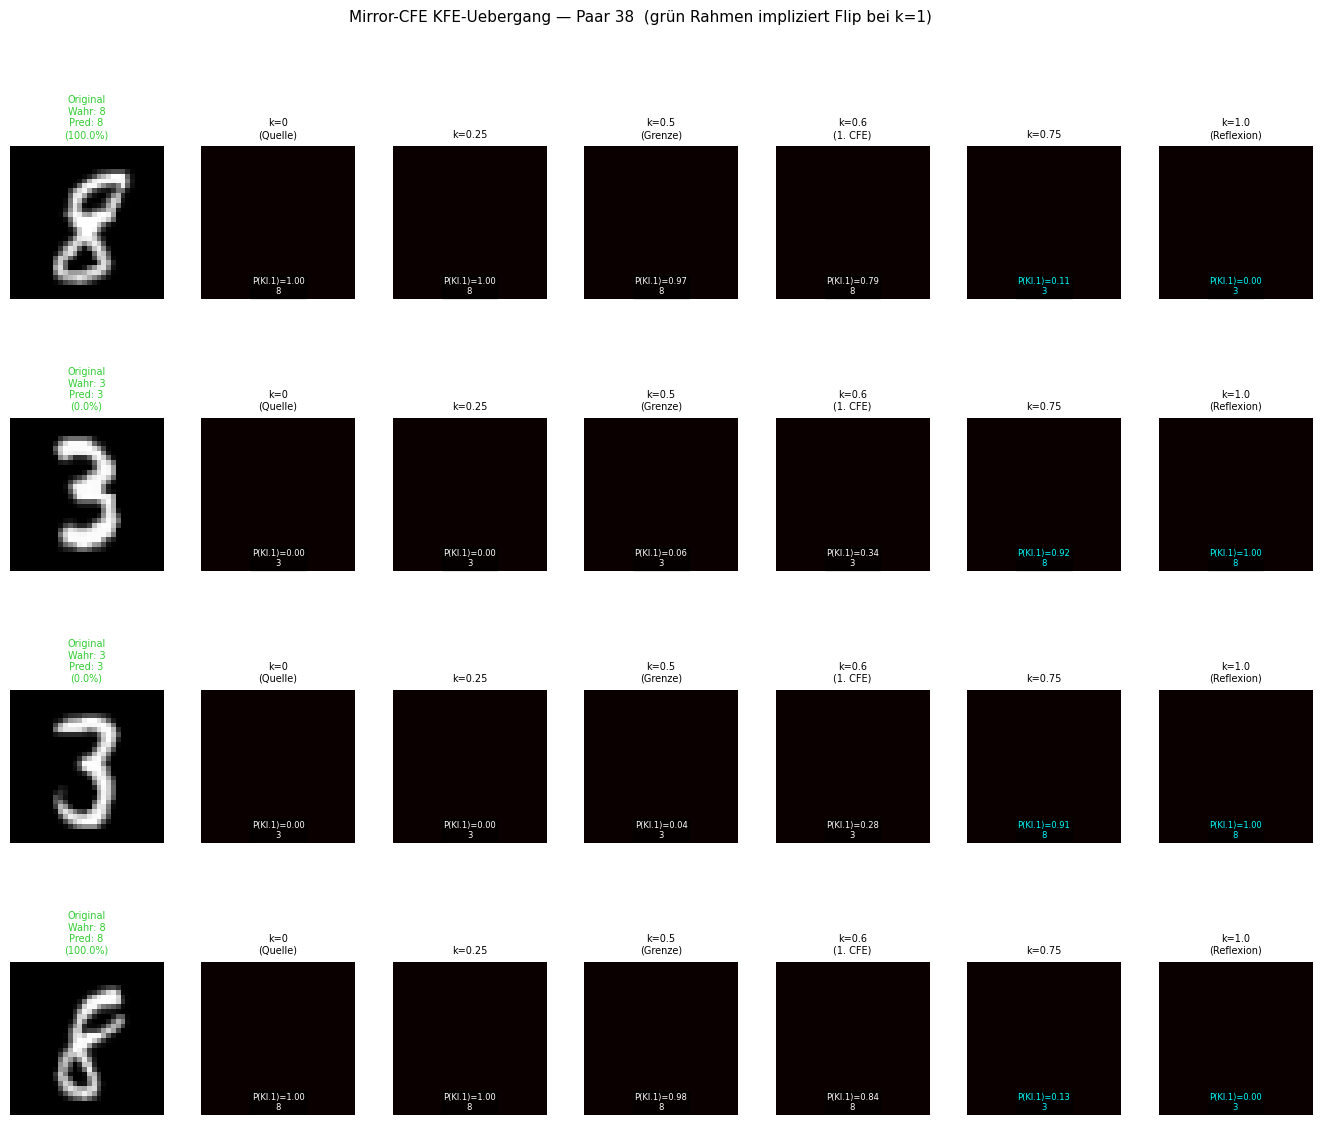

Gespeichert -> /kaggle/working/mirror_cfe_kfe_38.png


Mirror-CFE Evaluation: 100%|██████████| 10/10 [00:16<00:00,  1.64s/it]


Flip Rate: 640/640 = 100.00%
MirrorDecoder Parameter: 6,162,609
Discriminator Parameter: 659,905


Decoder Output: torch.Size([64, 1, 32, 32]) | Disc Output: torch.Size([64, 1, 4, 4])
Sanity: max|GAP(f^l_k) - z_k| = 0.00e+00  (sollte ~0 sein) OK
Loss-Funktionen definiert OK
Starte Mirror-Decoder Training...
Epochs: 15  LR: 0.0002  Batch: 64  alpha: 0.2  W_TRI: 2.0
----------------------------------------------------------------------


Ep 01/15:   0%|          | 0/168 [00:00<?, ?it/s]/tmp/ipykernel_23/3964203381.py:271: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  agg[kk] += float(vv) * B


...

Ep 11 | cls 0.1428  adv 1.620  rec 0.1523  fea 24.591  tri 0.0972  | val_cls(k=1) 0.2007


Ep 12 | cls 0.0922  adv 1.637  rec 0.1509  fea 24.004  tri 0.0962  | val_cls(k=1) 0.2410


Ep 13 | cls 0.0831  adv 1.804  rec 0.1491  fea 24.871  tri 0.1003  | val_cls(k=1) 0.2302


Ep 14 | cls 0.0895  adv 2.108  rec 0.1553  fea 24.165  tri 0.1010  | val_cls(k=1) 0.1316


Ep 15 | cls 0.0855  adv 2.477  rec 0.1466  fea 25.299  tri 0.0931  | val_cls(k=1) 0.3088

Training abgeschlossen OK
Mirror-Decoder gespeichert -> /kaggle/working/mirror_decoder_38.pth OK


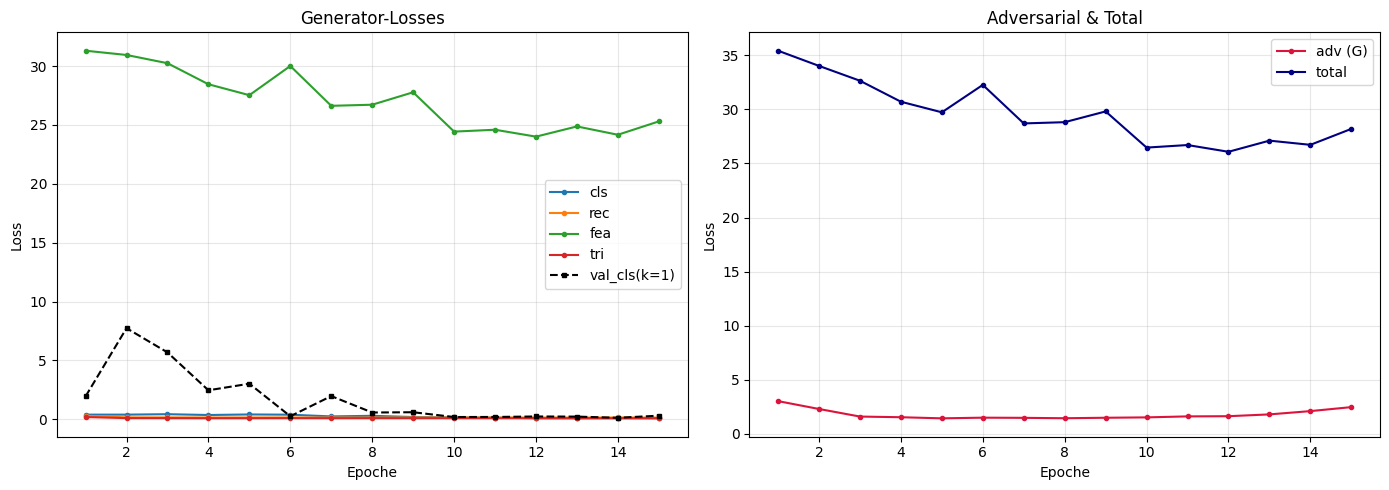

Kurven gespeichert OK
CFE-Flip-Rate (k=1, dieser Batch): 98.4%


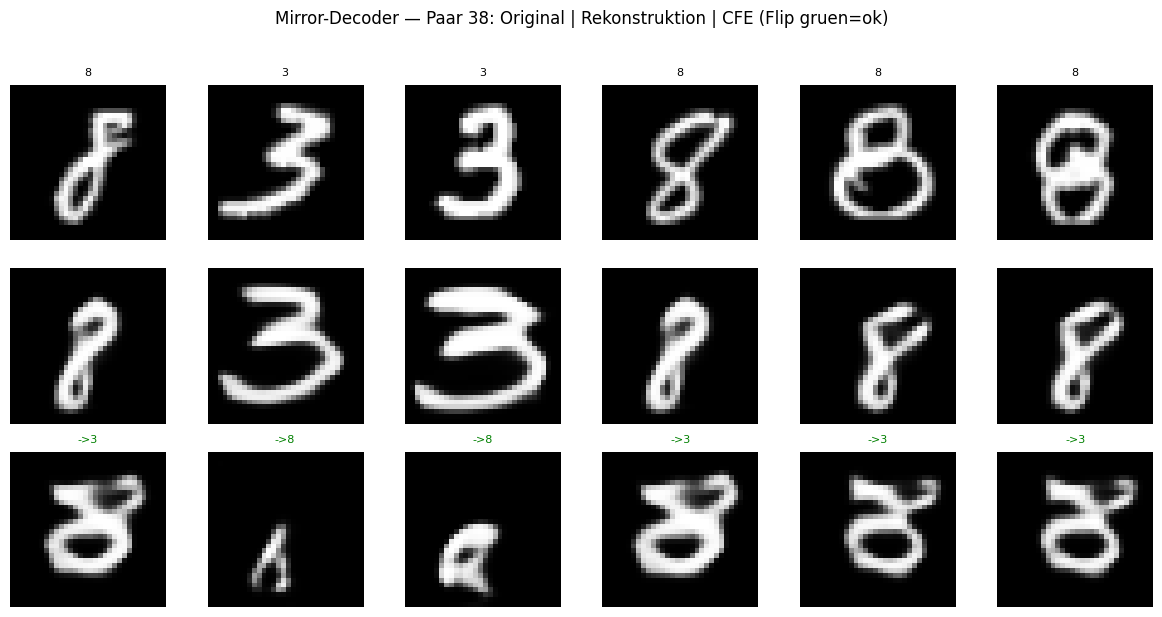

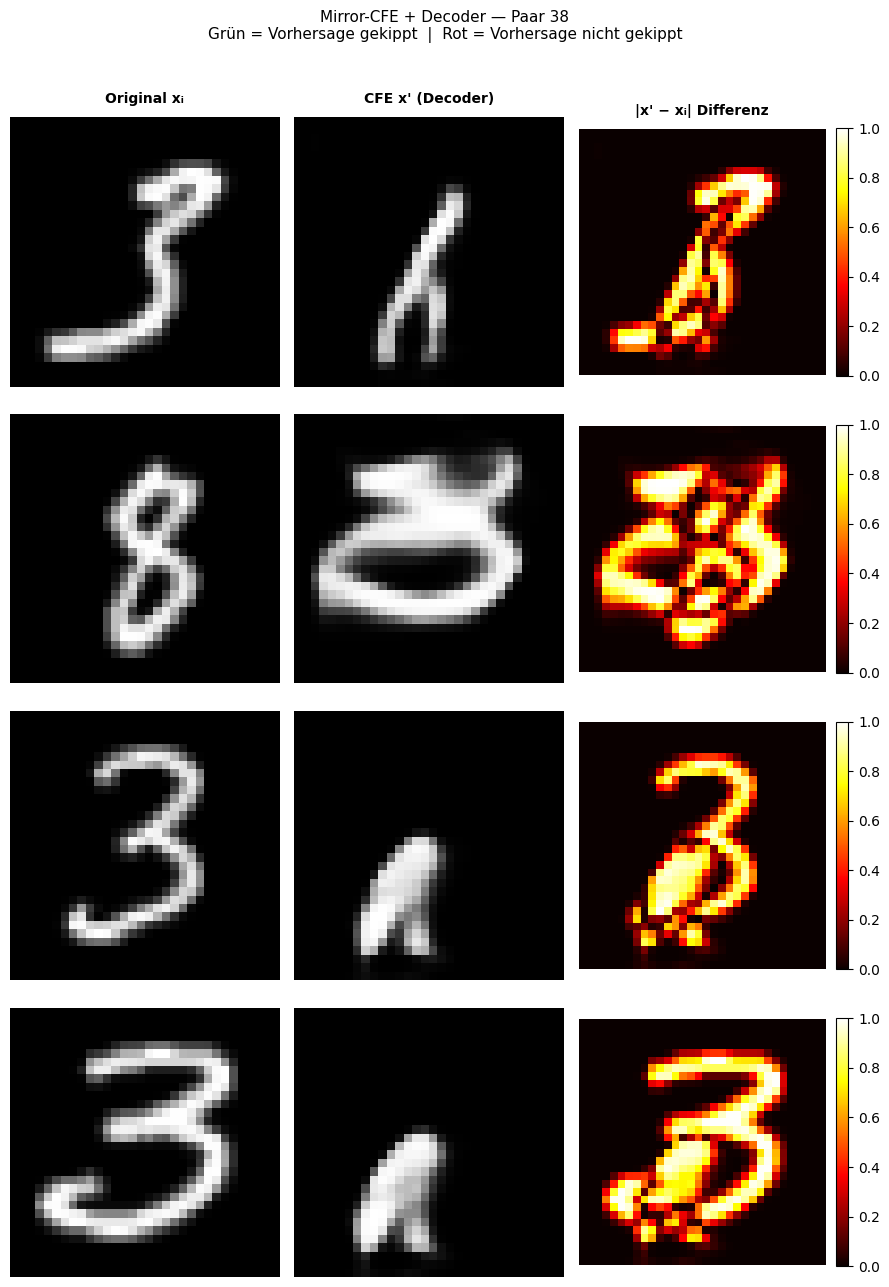

Gespeichert -> /kaggle/working/mirror_cfe_decoded_38.png
Fester Eval-Satz: 80 Bilder (Seed 42)

Berechne Metriken (first_cfe) ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation (first_cfe): 100%|██████████| 2/2 [00:02<00:00,  1.46s/it]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 158MB/s] 
/tmp/ipykernel_23/1343788489.py:128: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (first_cfe, 5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — Mirror-CFE MNIST Paar 38 (first_cfe)

-- Proximity --
  L1-Distanz:           0.1704  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.6925  (niedriger = besser)
  LPIPS (SqueezeNet):   0.1096  (niedriger = besser)

-- Plausibilitaet --
  FID:                  99.66   (niedriger = besser)

-- Funktionalitaet --
  Validity:             98.75%  (hoeher = besser)
  Denoised Validity:    43.75%  (hoeher = besser, sigma=1.0)
  Delta Validity:       55.00%  (niedriger = besser = weniger adversarial)
  Coverage:             98.75% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.028s / CF  (niedriger = besser)

Berechne Metriken (k1) ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation (k1): 100%|██████████| 2/2 [00:02<00:00,  1.23s/it]


Berechne Coverage (k1, 5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — Mirror-CFE MNIST Paar 38 (k1)

-- Proximity --
  L1-Distanz:           0.1811  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.7048  (niedriger = besser)
  LPIPS (SqueezeNet):   0.1236  (niedriger = besser)

-- Plausibilitaet --
  FID:                  123.86   (niedriger = besser)

-- Funktionalitaet --
  Validity:             98.75%  (hoeher = besser)
  Denoised Validity:    43.75%  (hoeher = besser, sigma=1.0)
  Delta Validity:       55.00%  (niedriger = besser = weniger adversarial)
  Coverage:             98.75% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.028s / CF  (niedriger = besser)

Beide Ergebnis-Zeilen (first_cfe + k1) fuer Paar 38 in /kaggle/working/metrics_summary_mirror.csv gespeichert.

######################################################################
# Mirror-CFE — Ziffernpaar 49 (4, 9)
#############################################################

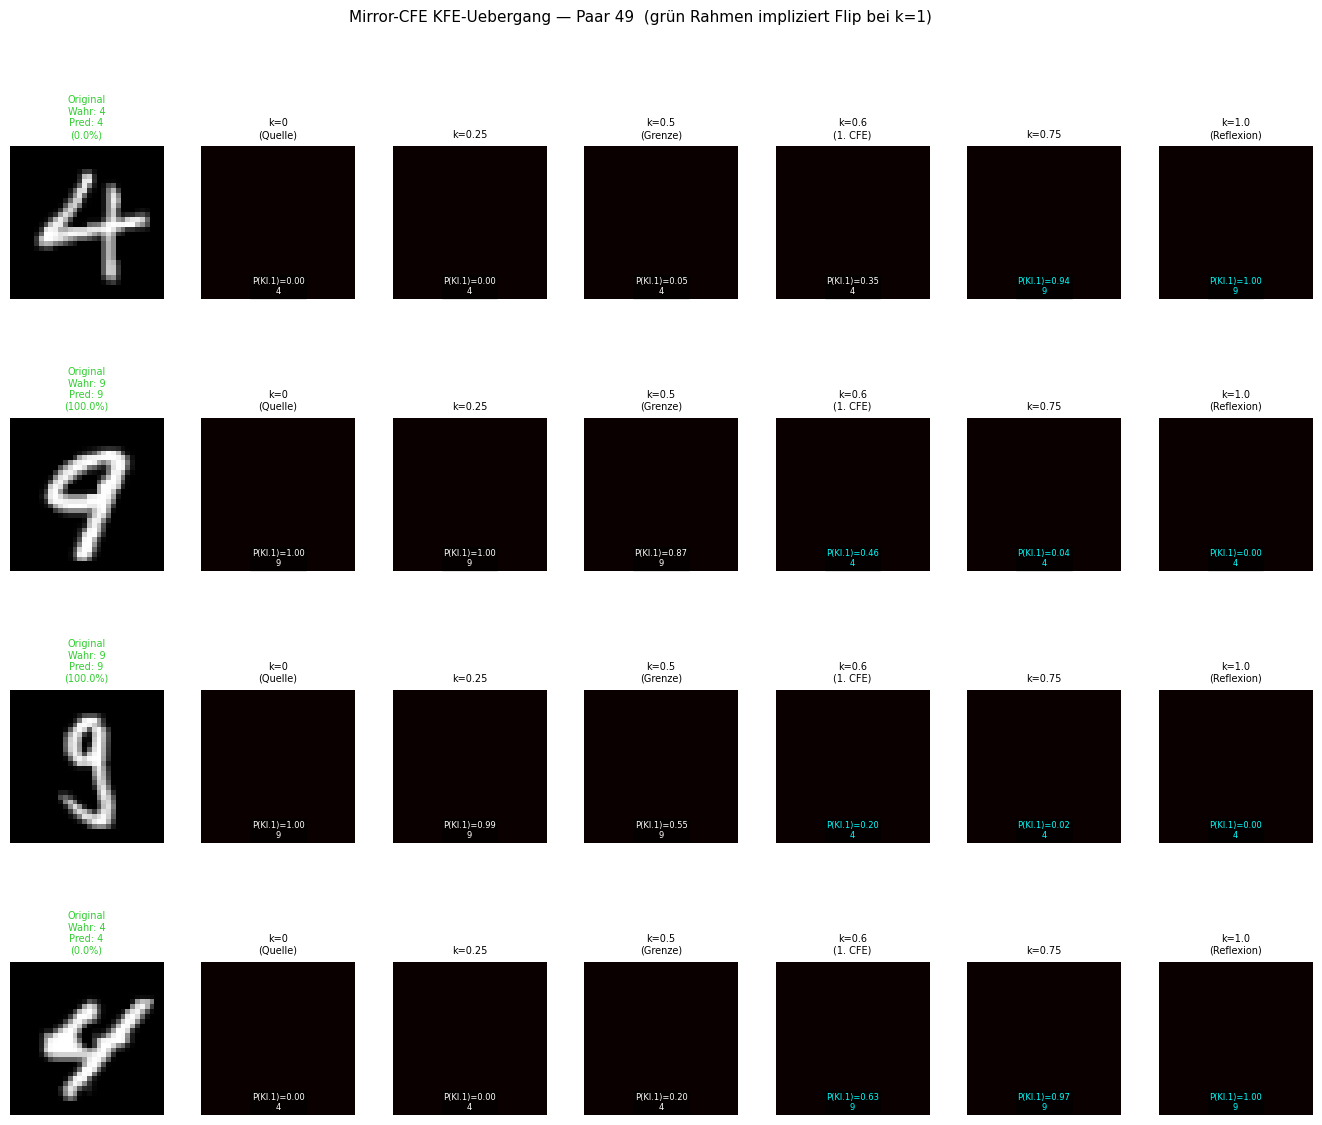

Gespeichert -> /kaggle/working/mirror_cfe_kfe_49.png


Mirror-CFE Evaluation: 100%|██████████| 10/10 [00:13<00:00,  1.33s/it]


Flip Rate: 640/640 = 100.00%
MirrorDecoder Parameter: 6,162,609
Discriminator Parameter: 659,905


Decoder Output: torch.Size([64, 1, 32, 32]) | Disc Output: torch.Size([64, 1, 4, 4])
Sanity: max|GAP(f^l_k) - z_k| = 0.00e+00  (sollte ~0 sein) OK
Loss-Funktionen definiert OK
Starte Mirror-Decoder Training...
Epochs: 15  LR: 0.0002  Batch: 64  alpha: 0.2  W_TRI: 2.0
----------------------------------------------------------------------


Ep 01 | cls 0.3646  adv 3.321  rec 0.2438  fea 27.942  tri 0.1483  | val_cls(k=1) 1.6777


...

Ep 11 | cls 0.2462  adv 1.506  rec 0.1345  fea 18.709  tri 0.0802  | val_cls(k=1) 0.4977


Ep 12 | cls 0.1729  adv 1.596  rec 0.1353  fea 19.881  tri 0.0819  | val_cls(k=1) 0.5105


Ep 13 | cls 0.1219  adv 1.655  rec 0.1276  fea 20.145  tri 0.0794  | val_cls(k=1) 0.4935


Ep 14 | cls 0.1267  adv 1.897  rec 0.1268  fea 22.296  tri 0.0808  | val_cls(k=1) 0.3619


Ep 15 | cls 0.1018  adv 2.316  rec 0.1270  fea 20.423  tri 0.0810  | val_cls(k=1) 0.4405

Training abgeschlossen OK
Mirror-Decoder gespeichert -> /kaggle/working/mirror_decoder_49.pth OK


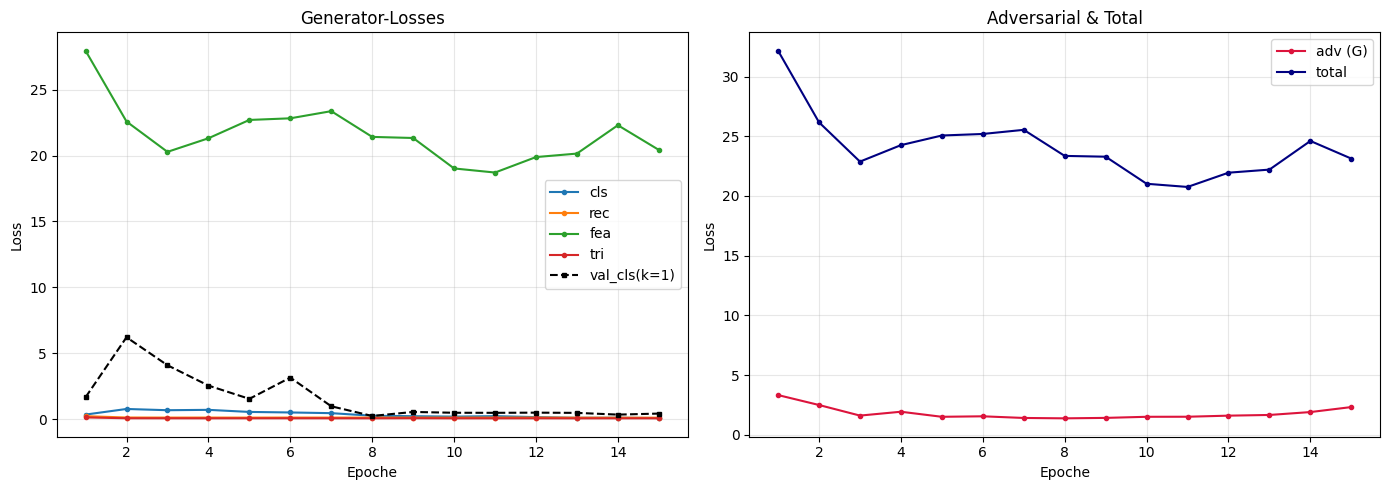

Kurven gespeichert OK
CFE-Flip-Rate (k=1, dieser Batch): 89.1%


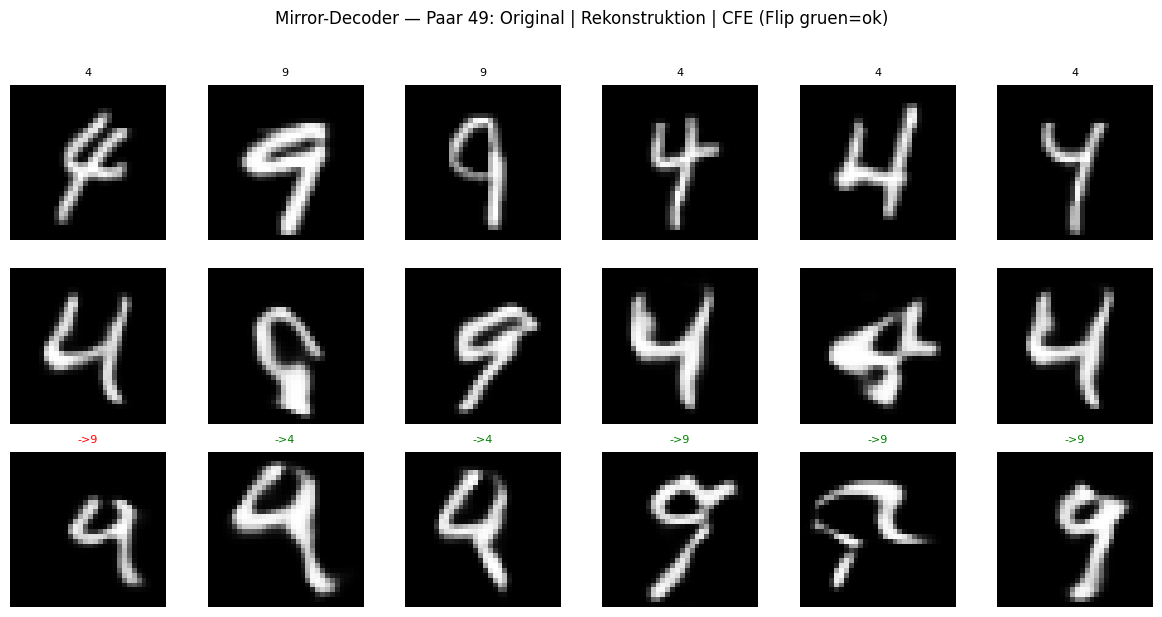

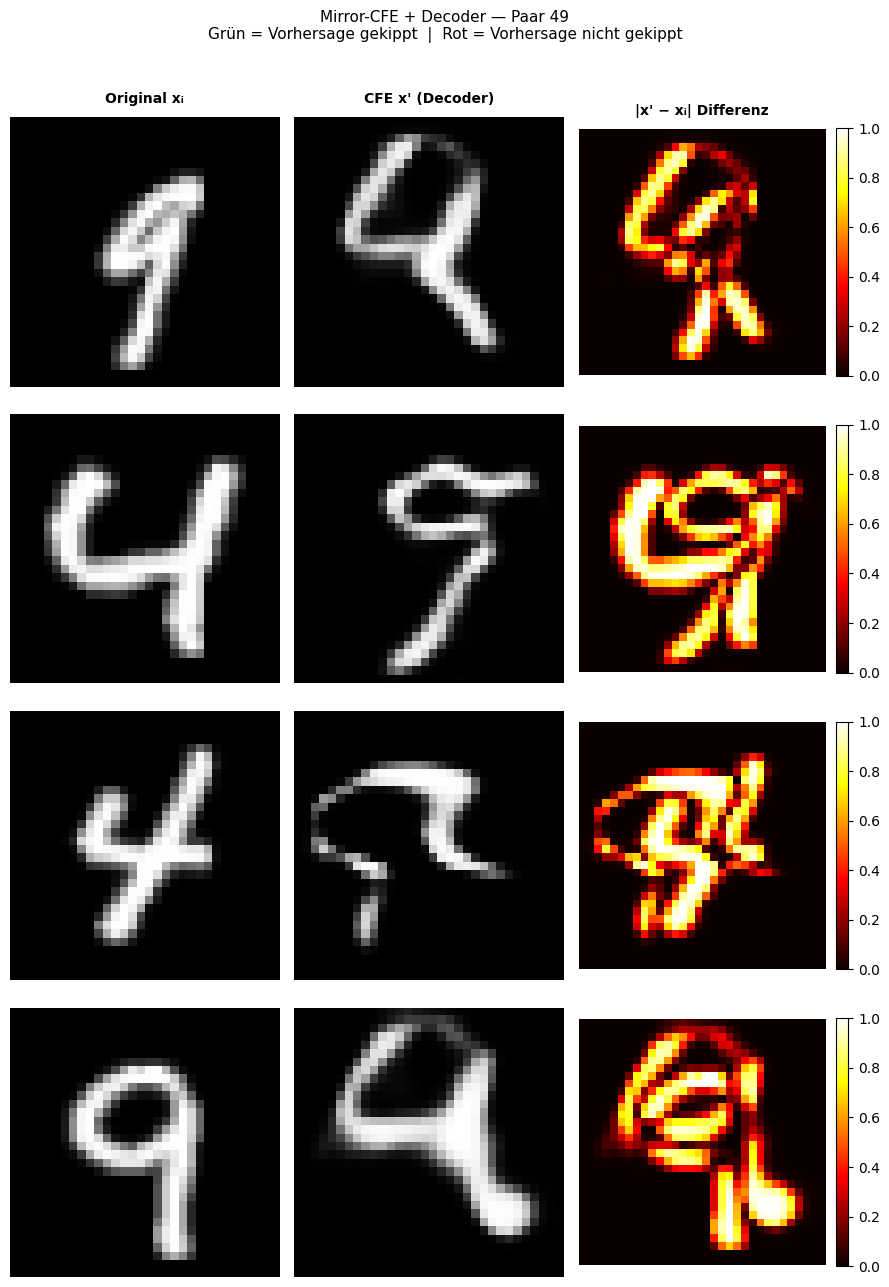

Gespeichert -> /kaggle/working/mirror_cfe_decoded_49.png
Fester Eval-Satz: 80 Bilder (Seed 42)

Berechne Metriken (first_cfe) ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation (first_cfe): 100%|██████████| 2/2 [00:02<00:00,  1.41s/it]
/tmp/ipykernel_23/1343788489.py:128: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (first_cfe, 5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — Mirror-CFE MNIST Paar 49 (first_cfe)

-- Proximity --
  L1-Distanz:           0.1435  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.5514  (niedriger = besser)
  LPIPS (SqueezeNet):   0.1255  (niedriger = besser)

-- Plausibilitaet --
  FID:                  88.85   (niedriger = besser)

-- Funktionalitaet --
  Validity:             93.75%  (hoeher = besser)
  Denoised Validity:    63.75%  (hoeher = besser, sigma=1.0)
  Delta Validity:       30.00%  (niedriger = besser = weniger adversarial)
  Coverage:             93.75% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.027s / CF  (niedriger = besser)

Berechne Metriken (k1) ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation (k1): 100%|██████████| 2/2 [00:02<00:00,  1.23s/it]


Berechne Coverage (k1, 5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — Mirror-CFE MNIST Paar 49 (k1)

-- Proximity --
  L1-Distanz:           0.1538  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.5850  (niedriger = besser)
  LPIPS (SqueezeNet):   0.1302  (niedriger = besser)

-- Plausibilitaet --
  FID:                  94.56   (niedriger = besser)

-- Funktionalitaet --
  Validity:             90.00%  (hoeher = besser)
  Denoised Validity:    92.50%  (hoeher = besser, sigma=1.0)
  Delta Validity:       -2.50%  (niedriger = besser = weniger adversarial)
  Coverage:             90.00% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.028s / CF  (niedriger = besser)

Beide Ergebnis-Zeilen (first_cfe + k1) fuer Paar 49 in /kaggle/working/metrics_summary_mirror.csv gespeichert.

######################################################################
# Mirror-CFE — Ziffernpaar 56 (5, 6)
##############################################################

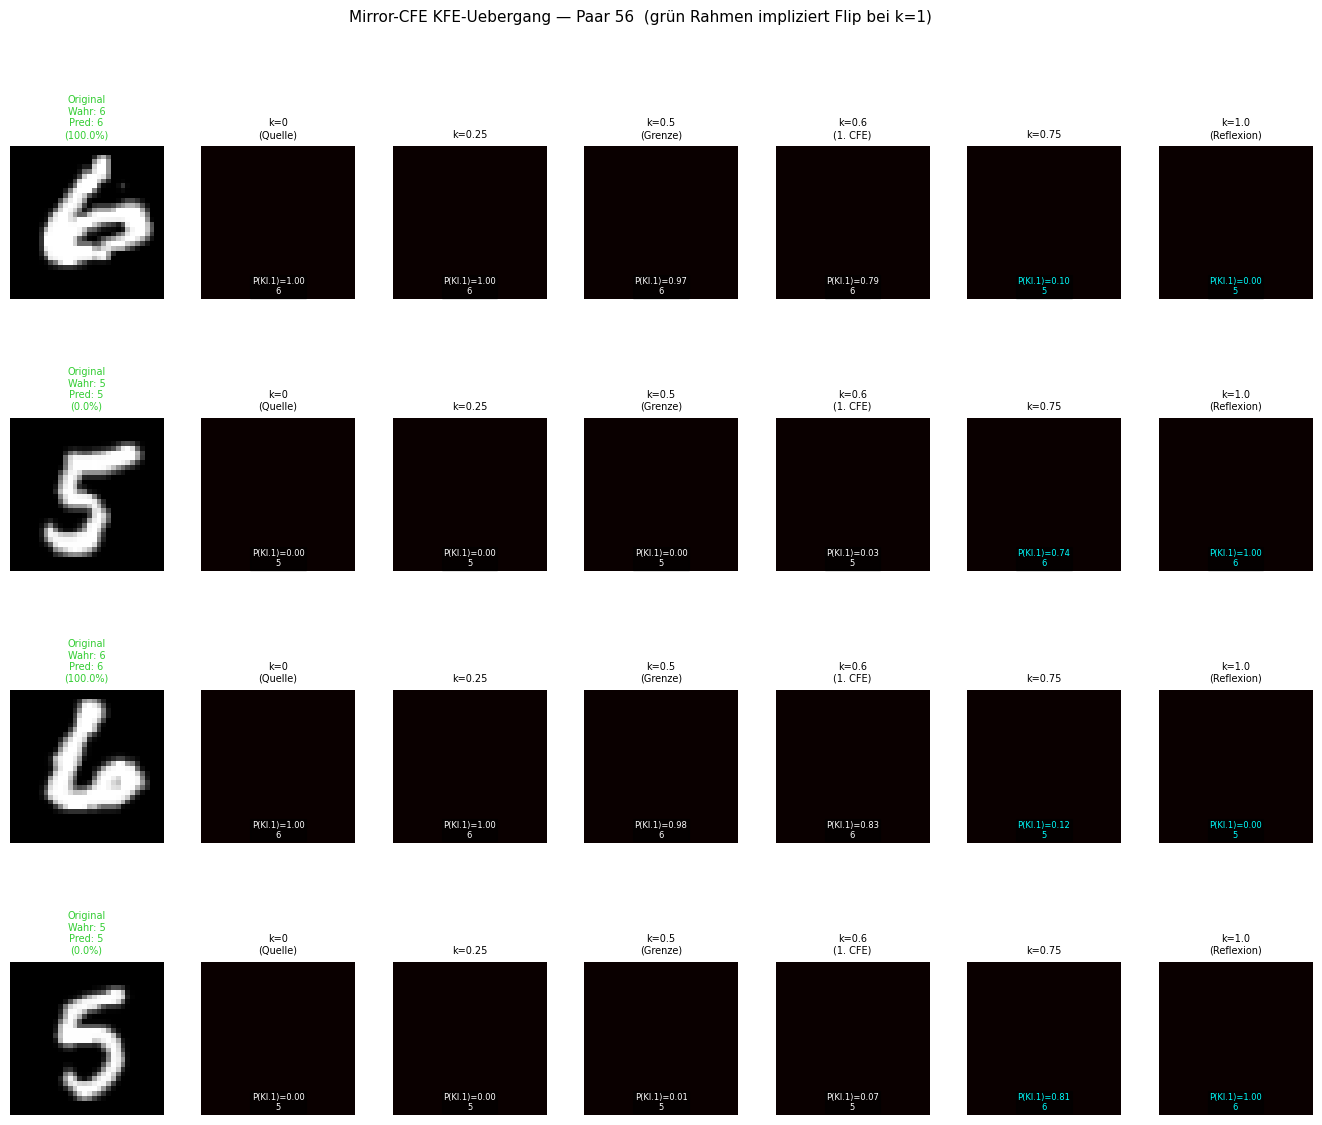

Gespeichert -> /kaggle/working/mirror_cfe_kfe_56.png


Mirror-CFE Evaluation: 100%|██████████| 10/10 [00:14<00:00,  1.40s/it]


Flip Rate: 640/640 = 100.00%
MirrorDecoder Parameter: 6,162,609
Discriminator Parameter: 659,905


Decoder Output: torch.Size([64, 1, 32, 32]) | Disc Output: torch.Size([64, 1, 4, 4])
Sanity: max|GAP(f^l_k) - z_k| = 0.00e+00  (sollte ~0 sein) OK
Loss-Funktionen definiert OK
Starte Mirror-Decoder Training...
Epochs: 15  LR: 0.0002  Batch: 64  alpha: 0.2  W_TRI: 2.0
----------------------------------------------------------------------


Ep 01 | cls 0.1853  adv 3.129  rec 0.2955  fea 25.605  tri 0.1605  | val_cls(k=1) 4.3492


...

Ep 11 | cls 0.1217  adv 1.354  rec 0.1475  fea 17.702  tri 0.0721  | val_cls(k=1) 0.9020


Ep 12 | cls 0.1474  adv 1.486  rec 0.1471  fea 20.223  tri 0.0709  | val_cls(k=1) 0.5642


Ep 13 | cls 0.1552  adv 1.550  rec 0.1469  fea 21.637  tri 0.0716  | val_cls(k=1) 0.6741


Ep 14 | cls 0.1213  adv 1.777  rec 0.1459  fea 19.901  tri 0.0716  | val_cls(k=1) 0.8447


Ep 15 | cls 0.1088  adv 2.172  rec 0.1478  fea 19.920  tri 0.0703  | val_cls(k=1) 0.5971

Training abgeschlossen OK
Mirror-Decoder gespeichert -> /kaggle/working/mirror_decoder_56.pth OK


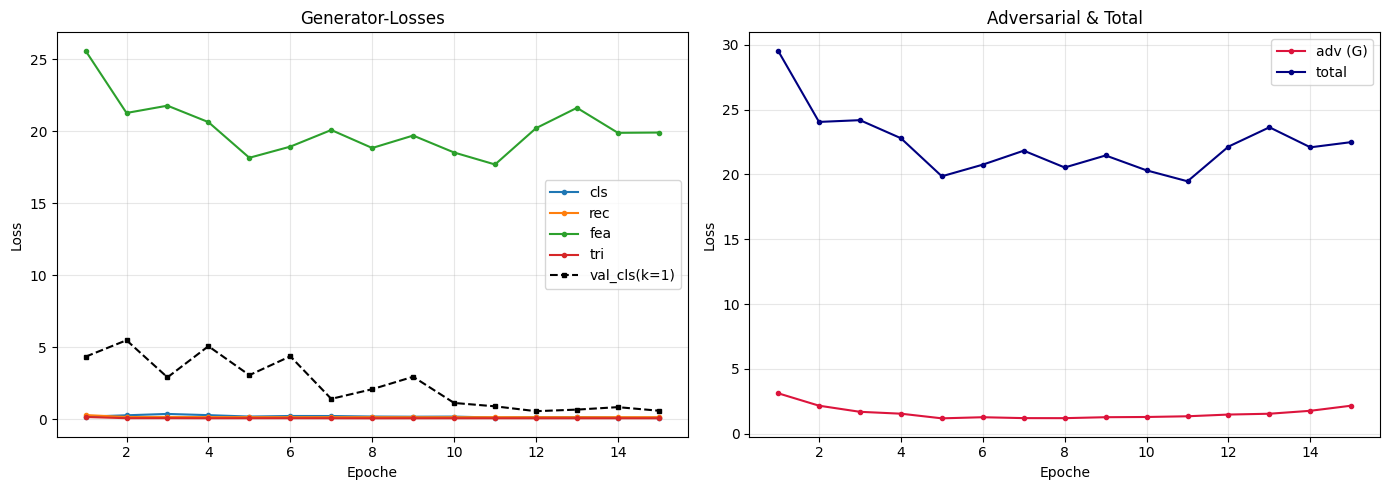

Kurven gespeichert OK
CFE-Flip-Rate (k=1, dieser Batch): 34.4%


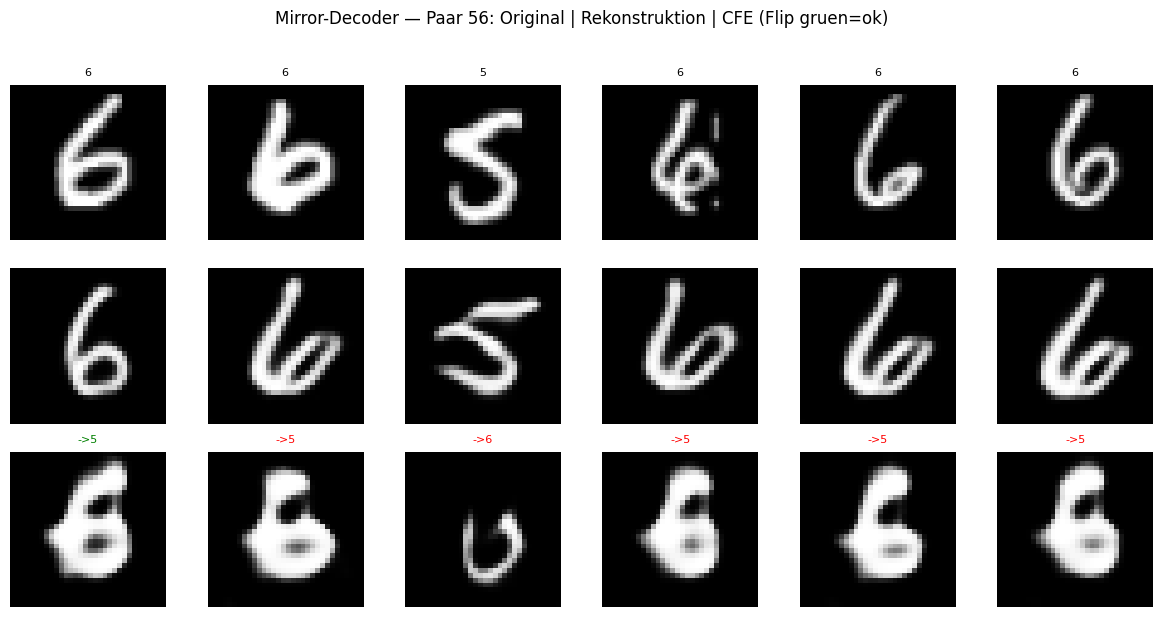

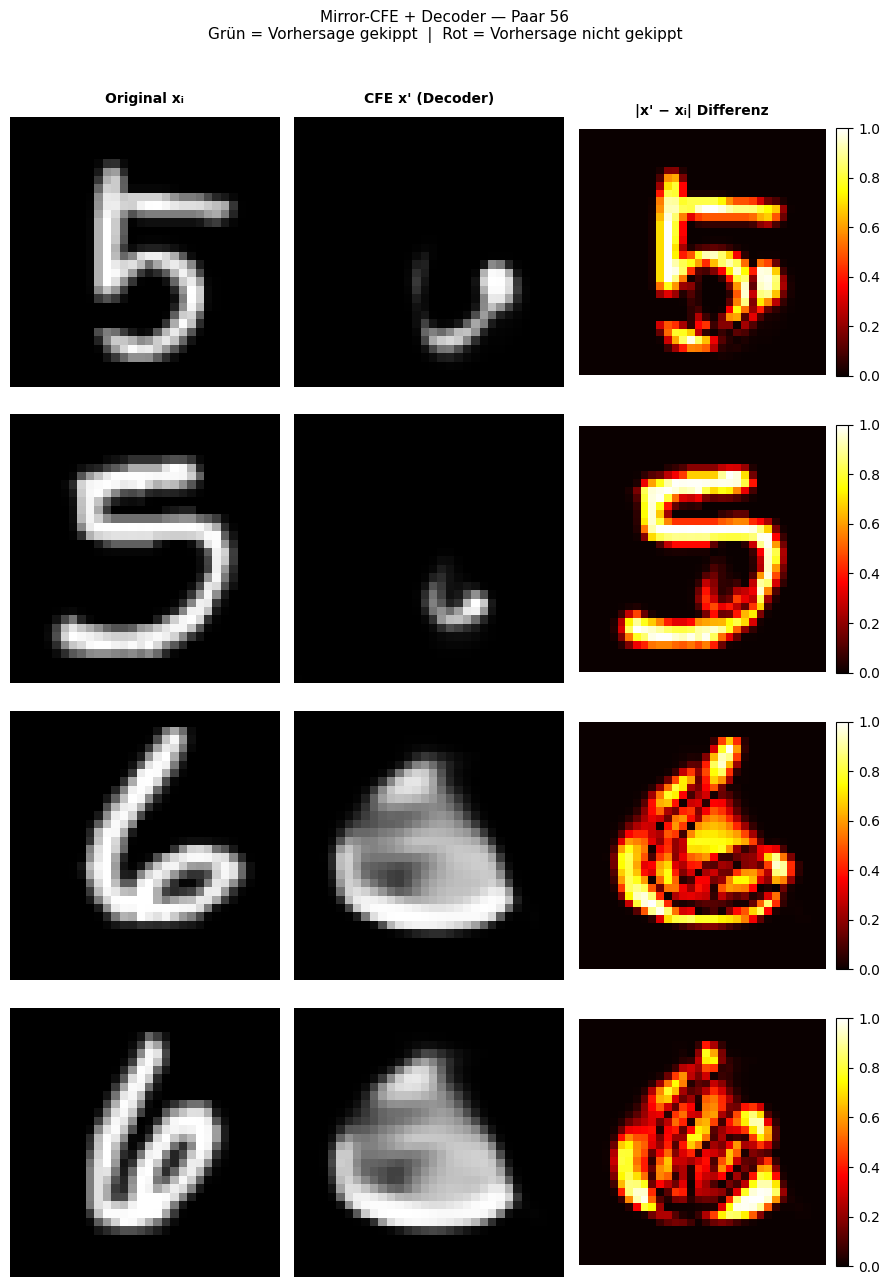

Gespeichert -> /kaggle/working/mirror_cfe_decoded_56.png
Fester Eval-Satz: 80 Bilder (Seed 42)

Berechne Metriken (first_cfe) ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation (first_cfe): 100%|██████████| 2/2 [00:04<00:00,  2.18s/it]


Berechne Coverage (first_cfe, 5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — Mirror-CFE MNIST Paar 56 (first_cfe)

-- Proximity --
  L1-Distanz:           0.1242  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.5390  (niedriger = besser)
  LPIPS (SqueezeNet):   0.0977  (niedriger = besser)

-- Plausibilitaet --
  FID:                  127.55   (niedriger = besser)

-- Funktionalitaet --
  Validity:             47.50%  (hoeher = besser)
  Denoised Validity:    45.00%  (hoeher = besser, sigma=1.0)
  Delta Validity:       2.50%  (niedriger = besser = weniger adversarial)
  Coverage:             47.50% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.047s / CF  (niedriger = besser)

Berechne Metriken (k1) ueber 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation (k1): 100%|██████████| 2/2 [00:03<00:00,  1.91s/it]


Berechne Coverage (k1, 5 Runs ueber den festen Eval-Satz)...

METRIK-ERGEBNISSE — Mirror-CFE MNIST Paar 56 (k1)

-- Proximity --
  L1-Distanz:           0.1237  (niedriger = besser)

-- Interpretierbarkeit --
  Sparsity Rate:        0.5270  (niedriger = besser)
  LPIPS (SqueezeNet):   0.1088  (niedriger = besser)

-- Plausibilitaet --
  FID:                  137.88   (niedriger = besser)

-- Funktionalitaet --
  Validity:             43.75%  (hoeher = besser)
  Denoised Validity:    46.25%  (hoeher = besser, sigma=1.0)
  Delta Validity:       -2.50%  (niedriger = besser = weniger adversarial)
  Coverage:             43.75% +/- 0.00%  (hoeher = besser)
  Efficiency:           0.045s / CF  (niedriger = besser)

Beide Ergebnis-Zeilen (first_cfe + k1) fuer Paar 56 in /kaggle/working/metrics_summary_mirror.csv gespeichert.

Alle 3 Ziffernpaare durchgelaufen (je 1x first_cfe, 1x k=1).


In [10]:
results_first_cfe = []
results_k1 = []
for _pk in TASK_PAIRS:
    _row_first, _row_k1 = run_mirror_pipeline(_pk)
    results_first_cfe.append(_row_first)
    results_k1.append(_row_k1)

print('\n' + '=' * 70)
print('Alle 3 Ziffernpaare durchgelaufen (je 1x first_cfe, 1x k=1).')
print('=' * 70)


## Mittelwert ueber alle 3 Ziffernpaare — beide k-Varianten

In [11]:
import pandas as pd
import csv as _csv

numeric_cols = ['l1', 'sparsity_rate', 'lpips', 'fid', 'validity', 'denoised_validity',
                'delta_validity', 'coverage_mean', 'coverage_std', 'efficiency_sec']

def _mean_row(results, variant_label):
    df = pd.DataFrame(results)
    mean_row = {'method': 'Mirror-CFE', 'variant': variant_label, 'pair_key': 'MEAN',
                'digit_pair': 'Mittelwert ueber alle 3 Paare'}
    for col in numeric_cols:
        vals = pd.to_numeric(df[col], errors='coerce')
        mean_row[col] = round(float(vals.mean()), 4)
    mean_row['n_eval'] = N_EVAL_IMAGES
    mean_row['eval_seed'] = EVAL_SEED
    return mean_row

mean_first_cfe = _mean_row(results_first_cfe, 'first_cfe')
mean_k1        = _mean_row(results_k1, 'k1')

# Mittelwert-Zeilen in die CSV anhaengen (ersetzt alte MEAN-Zeilen)
SUMMARY_PATH = os.path.join(OUT_DIR, 'metrics_summary_mirror.csv')
existing_rows = []
if os.path.exists(SUMMARY_PATH):
    with open(SUMMARY_PATH, newline='') as f:
        existing_rows = list(_csv.DictReader(f))
existing_rows = [r for r in existing_rows if r['pair_key'] != 'MEAN']
existing_rows.append({k: str(v) for k, v in mean_first_cfe.items()})
existing_rows.append({k: str(v) for k, v in mean_k1.items()})
fieldnames = list(existing_rows[0].keys()) if existing_rows else list(mean_first_cfe.keys())
with open(SUMMARY_PATH, 'w', newline='') as f:
    writer = _csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(existing_rows)

for label, mean_row in [('1st-CFE (Standard)', mean_first_cfe), ('k=1 (voller Reflexionspunkt)', mean_k1)]:
    print('=' * 70)
    print(f'METRIK-ERGEBNISSE — Mirror-CFE MNIST — MITTELWERT ueber alle 3 Ziffernpaare — {label}')
    print('=' * 70)
    print(f"\n-- Proximity --")
    print(f"  L1-Distanz:           {mean_row['l1']:.4f}")
    print(f"\n-- Interpretierbarkeit --")
    print(f"  Sparsity Rate:        {mean_row['sparsity_rate']:.4f}")
    print(f"  LPIPS (SqueezeNet):   {mean_row['lpips']:.4f}")
    print(f"\n-- Plausibilitaet --")
    print(f"  FID:                  {mean_row['fid']:.2f}")
    print(f"\n-- Funktionalitaet --")
    print(f"  Validity:             {mean_row['validity']:.2%}")
    print(f"  Denoised Validity:    {mean_row['denoised_validity']:.2%}")
    print(f"  Delta Validity:       {mean_row['delta_validity']:.2%}")
    print(f"  Coverage:             {mean_row['coverage_mean']:.2%} +/- {mean_row['coverage_std']:.2%}")
    print(f"  Efficiency:           {mean_row['efficiency_sec']:.3f}s / CF")
    print('=' * 70)
    print()

df_display = pd.DataFrame(results_first_cfe + [mean_first_cfe] + results_k1 + [mean_k1])
df_display


METRIK-ERGEBNISSE — Mirror-CFE MNIST — MITTELWERT ueber alle 3 Ziffernpaare — 1st-CFE (Standard)

-- Proximity --
  L1-Distanz:           0.1460

-- Interpretierbarkeit --
  Sparsity Rate:        0.5943
  LPIPS (SqueezeNet):   0.1109

-- Plausibilitaet --
  FID:                  105.35

-- Funktionalitaet --
  Validity:             80.00%
  Denoised Validity:    50.83%
  Delta Validity:       29.17%
  Coverage:             80.00% +/- 0.00%
  Efficiency:           0.034s / CF

METRIK-ERGEBNISSE — Mirror-CFE MNIST — MITTELWERT ueber alle 3 Ziffernpaare — k=1 (voller Reflexionspunkt)

-- Proximity --
  L1-Distanz:           0.1529

-- Interpretierbarkeit --
  Sparsity Rate:        0.6056
  LPIPS (SqueezeNet):   0.1209

-- Plausibilitaet --
  FID:                  118.77

-- Funktionalitaet --
  Validity:             77.50%
  Denoised Validity:    60.83%
  Delta Validity:       16.67%
  Coverage:             77.50% +/- 0.00%
  Efficiency:           0.034s / CF



,method,variant,pair_key,digit_pair,l1,sparsity_rate,lpips,fid,validity,denoised_validity,delta_validity,coverage_mean,coverage_std,efficiency_sec,n_eval,eval_seed
0,Mirror-CFE,first_cfe,38,3-8,0.1704,0.6925,0.1096,99.6600,0.9875,0.4375,0.5500,0.9875,0.0,0.0278,80,42
1,Mirror-CFE,first_cfe,49,4-9,0.1435,0.5514,0.1255,88.8500,0.9375,0.6375,0.3000,0.9375,0.0,0.0275,80,42
2,Mirror-CFE,first_cfe,56,5-6,0.1242,0.5390,0.0977,127.5500,0.4750,0.4500,0.0250,0.4750,0.0,0.0465,80,42
3,Mirror-CFE,first_cfe,MEAN,Mittelwert ueber alle 3 Paare,0.1460,0.5943,0.1109,105.3533,0.8000,0.5083,0.2917,0.8000,0.0,0.0339,80,42
4,Mirror-CFE,k1,38,3-8,0.1811,0.7048,0.1236,123.8600,0.9875,0.4375,0.5500,0.9875,0.0,0.0283,80,42
5,Mirror-CFE,k1,49,4-9,0.1538,0.5850,0.1302,94.5600,0.9000,0.9250,-0.0250,0.9000,0.0,0.0284,80,42
6,Mirror-CFE,k1,56,5-6,0.1237,0.5270,0.1088,137.8800,0.4375,0.4625,-0.0250,0.4375,0.0,0.0451,80,42
7,Mirror-CFE,k1,MEAN,Mittelwert ueber alle 3 Paare,0.1529,0.6056,0.1209,118.7667,0.7750,0.6083,0.1667,0.7750,0.0,0.0339,80,42
